## Throughput

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/nr_4/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_8/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_16/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/nr_32/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_48/tsm-sc-001/node2/stellar-core.log']


throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # # ---- Plot Throughput ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    # plt.xlabel("Time (s)")
    # plt.ylabel("Transactions/sec")
    # plt.ylim(0, throughput.values.max() * 1.2)
    # plt.title("Throughput vs Time (Normal Consensus Only)")
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("throughput.png", dpi=150)
    # plt.show()
    
    # # ---- Plot Latency ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    # plt.xlabel("Time (s)")
    # plt.ylabel("Latency (s)")
    # plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("latency.png", dpi=150)
    # plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

# Collection Plots

Processing: ../work/experiments/stellar-core/collection_100_rounds_4_v2/tsm-sc-001/node2/stellar-core.log
Proposals parsed: 96104
Commits parsed:   130436
COLLECT views:    100


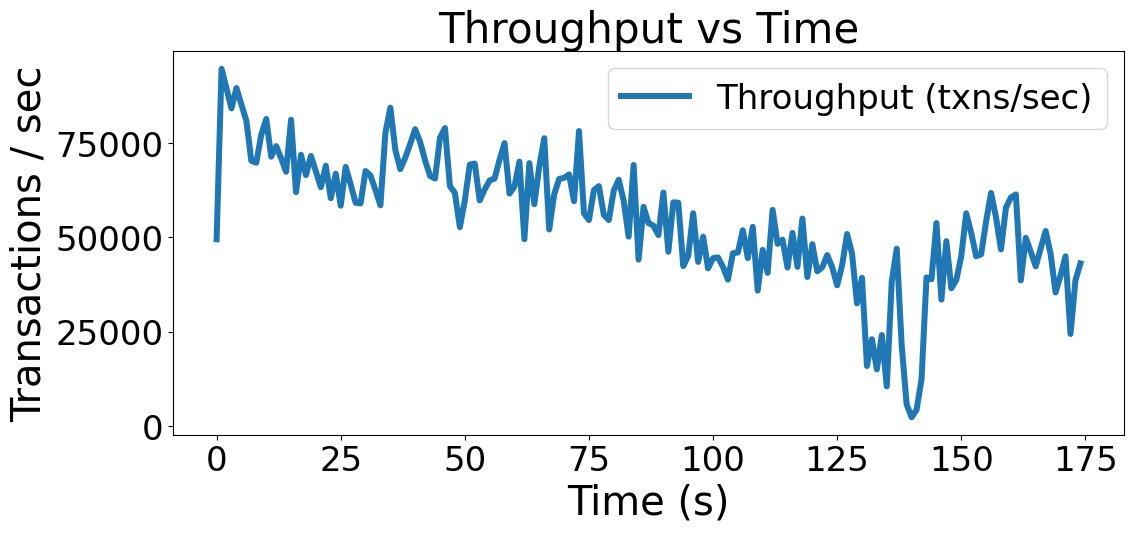

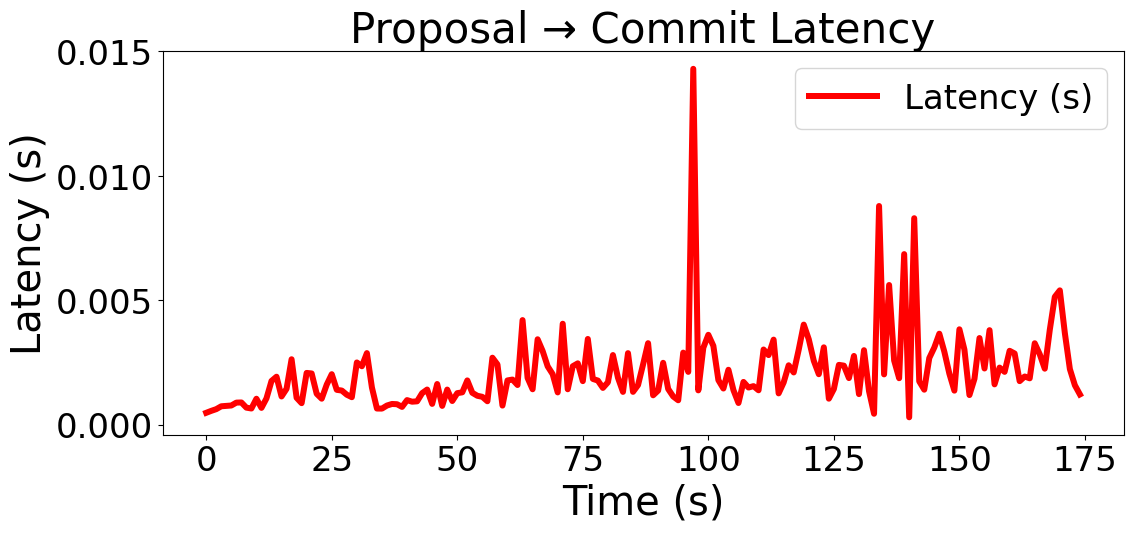

Average Throughput: 40836.666666666664
Average Latency: 0.0026154973179591786
Processing: ../work/experiments/stellar-core/collection_100_rounds_8_v2/tsm-sc-001/node2/stellar-core.log
Proposals parsed: 36524
Commits parsed:   36944
COLLECT views:    100


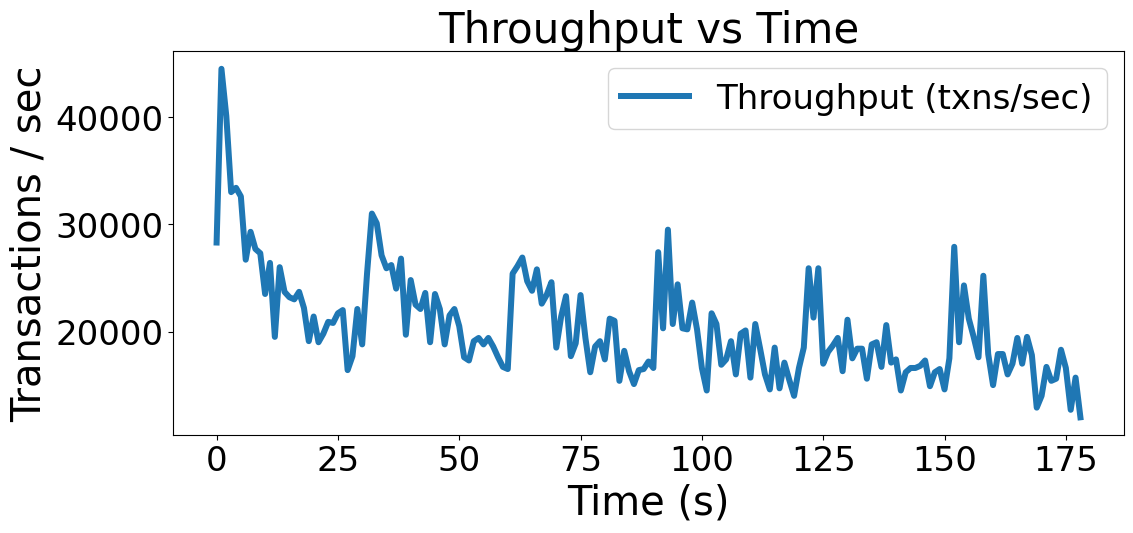

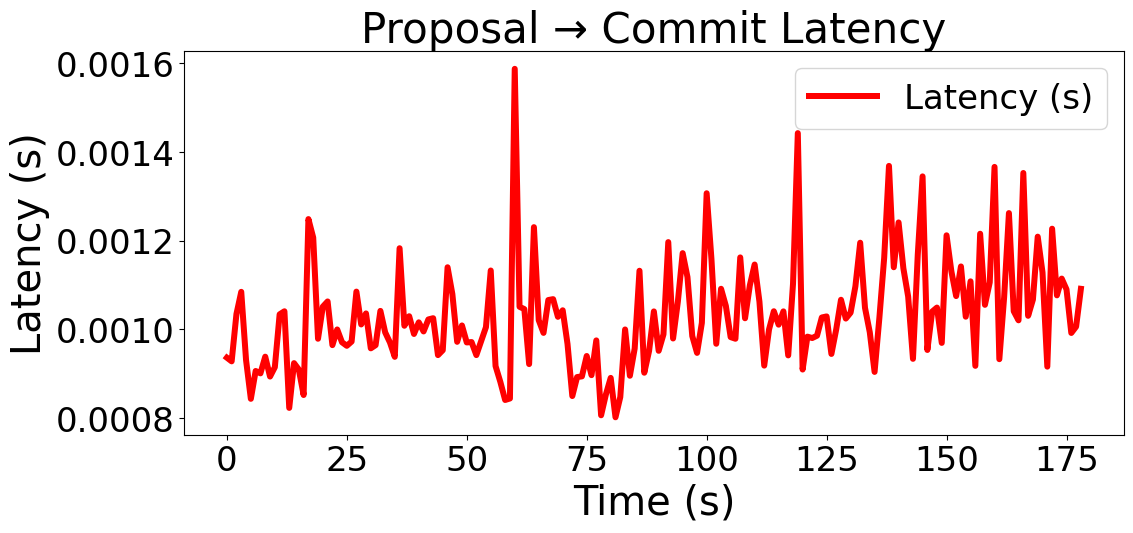

Average Throughput: 18581.666666666668
Average Latency: 0.0010644387099151686
Processing: ../work/experiments/stellar-core/collection_100_rounds_16_v2/tsm-sc-001/node2/stellar-core.log
Proposals parsed: 45475
Commits parsed:   45763
COLLECT views:    100


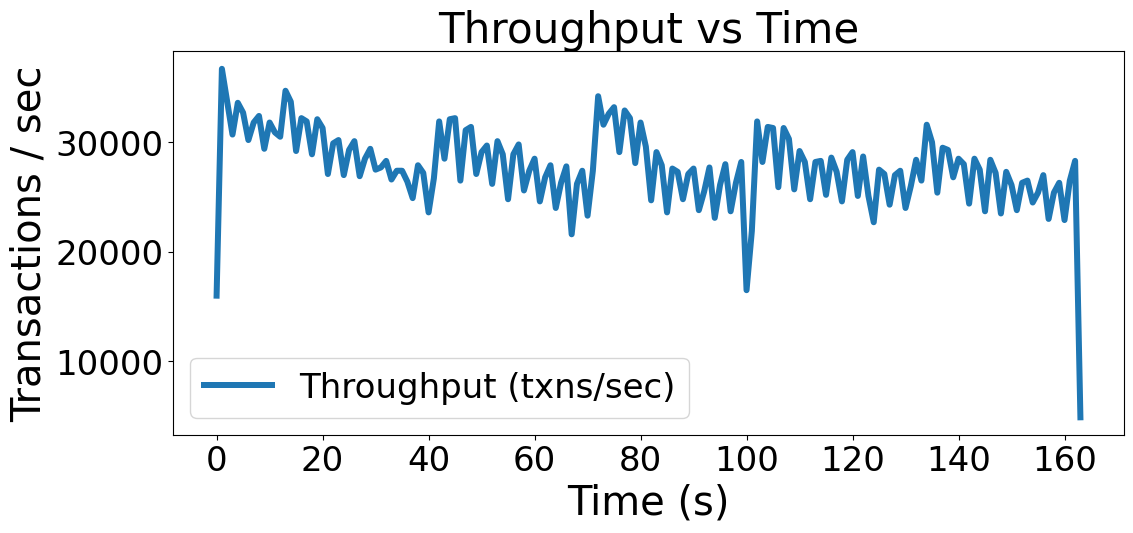

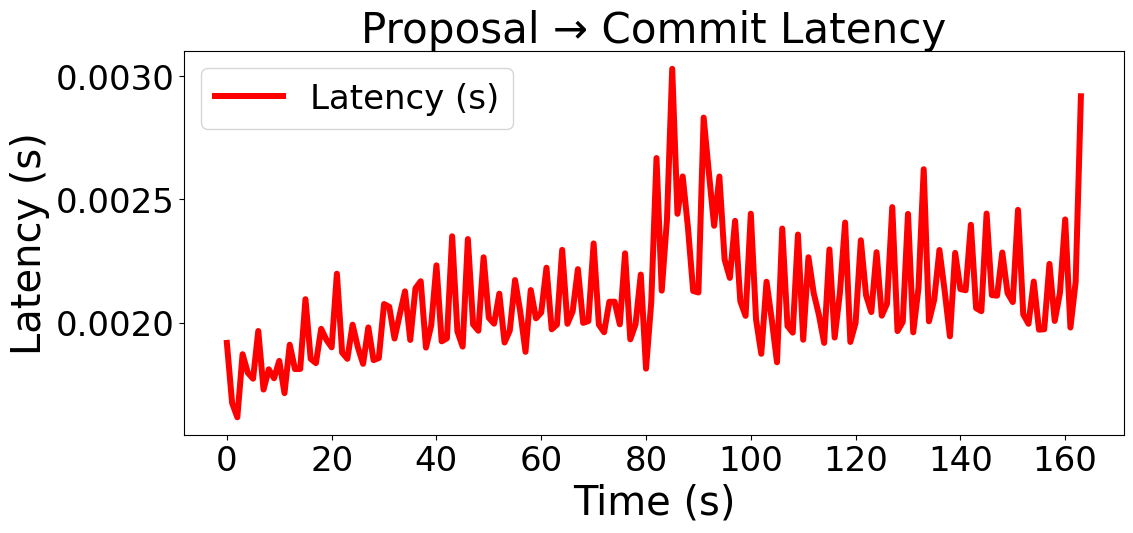

Average Throughput: 27295.0
Average Latency: 0.002203078116111366
Processing: ../work/experiments/stellar-core/collection_100_rounds_32_v2/tsm-sc-001/node2/stellar-core.log
Proposals parsed: 9845
Commits parsed:   15732
COLLECT views:    100


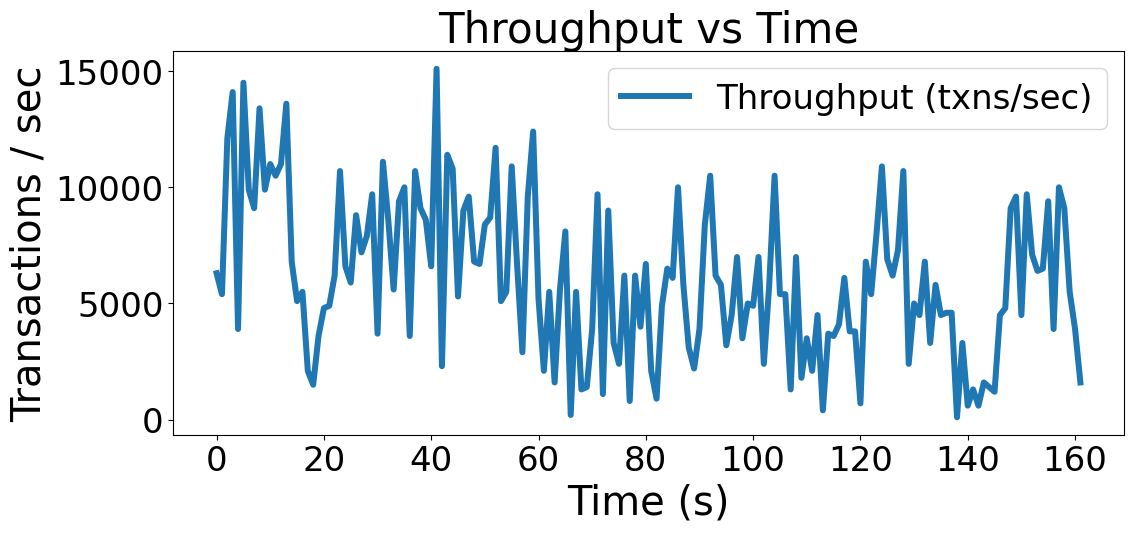

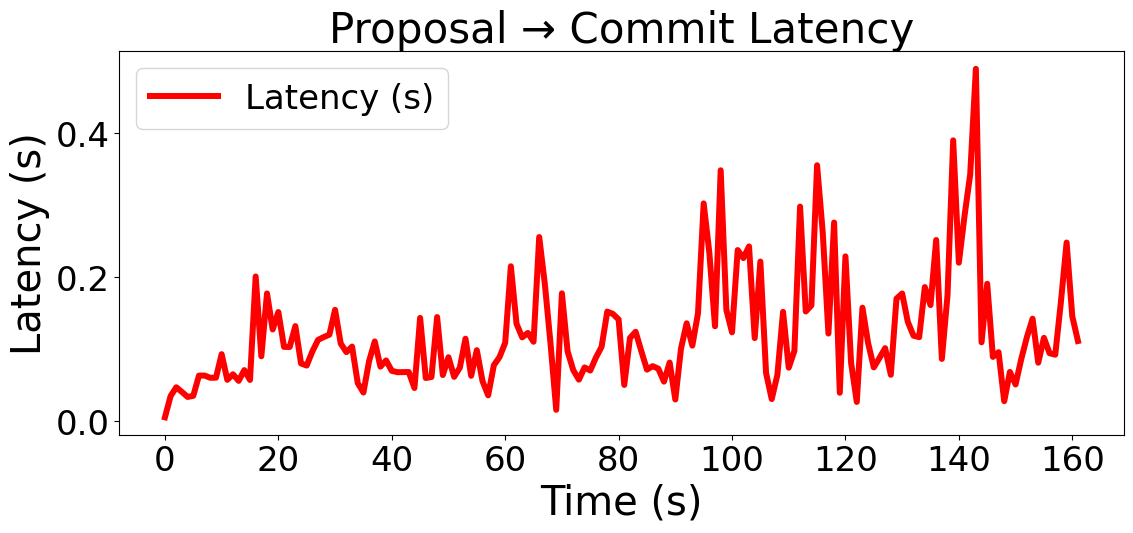

Average Throughput: 5020.0
Average Latency: 0.1348002038038216


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = [
                '../work/experiments/stellar-core/collection_100_rounds_4_v2/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_100_rounds_8_v2/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_100_rounds_16_v2/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_100_rounds_32_v2/tsm-sc-001/node2/stellar-core.log']



throughput_list = []
latency_list = []

# -----------------------------
# Regex patterns
# -----------------------------

# ALL ways a proposal can appear
propose_patterns = [
    re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    ),
    re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Leader proposing block (\w+) in view (\d+)"
    ),
    re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"CUSTOM_READY: Leader proposing block (\w+) in view (\d+)"
    ),
]

# Commit log
commit_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Committed block (\w+) at view (\d+) with (\d+) transactions"
)

# COLLECT views
collect_pattern = re.compile(r"Received COLLECT for view (\d+)")

# -----------------------------
# Parse logs
# -----------------------------
for log_file in log_file_list:
    print(f"Processing: {log_file}")

    propose_times = {}      # (block, view) -> earliest proposal time
    commit_times = {}       # (block, view) -> commit time
    batch_sizes = {}        # (block, view) -> txn count
    collect_views = set()   # views where COLLECT happened

    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            m = collect_pattern.search(line)
            if m:
                collect_views.add(int(m.group(1)))

            # Match ALL proposal forms
            for pat in propose_patterns:
                pm = pat.search(line)
                if pm:
                    ts = datetime.strptime(
                        pm.group(1), "%Y-%m-%dT%H:%M:%S.%f"
                    )
                    block = pm.group(2)
                    view = int(pm.group(3))
                    key = (block, view)

                    # Keep EARLIEST proposal time
                    if key not in propose_times or ts < propose_times[key]:
                        propose_times[key] = ts

            # Match COMMIT
            cm = commit_pattern.search(line)
            if cm:
                ts = datetime.strptime(
                    cm.group(1), "%Y-%m-%dT%H:%M:%S.%f"
                )
                block = cm.group(2)
                view = int(cm.group(3))
                batch = int(cm.group(4))

                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch

    print(f"Proposals parsed: {len(propose_times)}")
    print(f"Commits parsed:   {len(commit_times)}")
    print(f"COLLECT views:    {len(collect_views)}")

    # -----------------------------
    # Build latency + throughput data
    # -----------------------------
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []

    for key, ctime in commit_times.items():
        block, view = key

        # OPTIONAL: exclude COLLECT rounds entirely
        # if view in collect_views:
        #     continue

        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch = batch_sizes[key]

            latencies.append({
                "commit_time": ctime,
                "latency": latency
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch)

    if not commit_timestamps:
        print("No valid commits found.")
        continue

    # -----------------------------
    # Normalize time
    # -----------------------------
    start_time = min(commit_timestamps + list(propose_times.values()))

    # -----------------------------
    # Throughput (txns/sec)
    # -----------------------------
    commit_data = []
    for ts, txns in zip(commit_timestamps, commit_txn_counts):
        t = (ts - start_time).total_seconds()
        commit_data.append({"time": t, "txns": txns})

    df = pd.DataFrame(commit_data)
    df["time_round"] = df["time"].round().astype(int)

    throughput = df.groupby("time_round")["txns"].sum()

    full_index = np.arange(
        int(throughput.index.min()),
        int(throughput.index.max()) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)

    # -----------------------------
    # Latency (avg per second)
    # -----------------------------
    lat_df = pd.DataFrame(latencies)
    lat_df["time"] = lat_df["commit_time"].apply(
        lambda t: (t - start_time).total_seconds()
    )
    lat_df["time_round"] = lat_df["time"].round().astype(int)

    latency_series = lat_df.groupby("time_round")["latency"].mean()

    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)

    # -----------------------------
    # Plot Throughput
    # -----------------------------
    plt.figure(figsize=(12, 6))
    plt.plot(
        throughput.index,
        throughput.values,
        label="Throughput (txns/sec)"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions / sec")
    plt.title("Throughput vs Time")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()

    # -----------------------------
    # Plot Latency
    # -----------------------------
    plt.figure(figsize=(12, 6))
    plt.plot(
        latency_series.index,
        latency_series.values,
        color="red",
        label="Latency (s)"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()

    print(
        "Average Throughput:",
        np.mean(throughput.values[-90:-30])
    )
    print(
        "Average Latency:",
        np.mean(latency_series.values[-90:-30])
    )

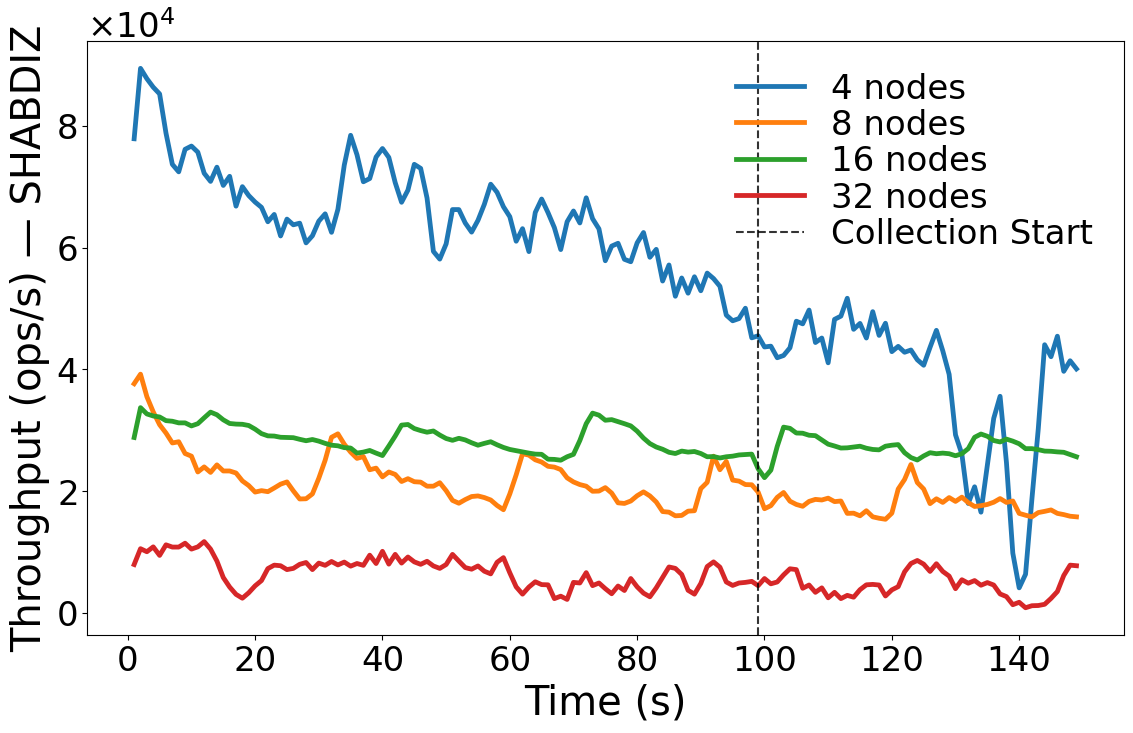

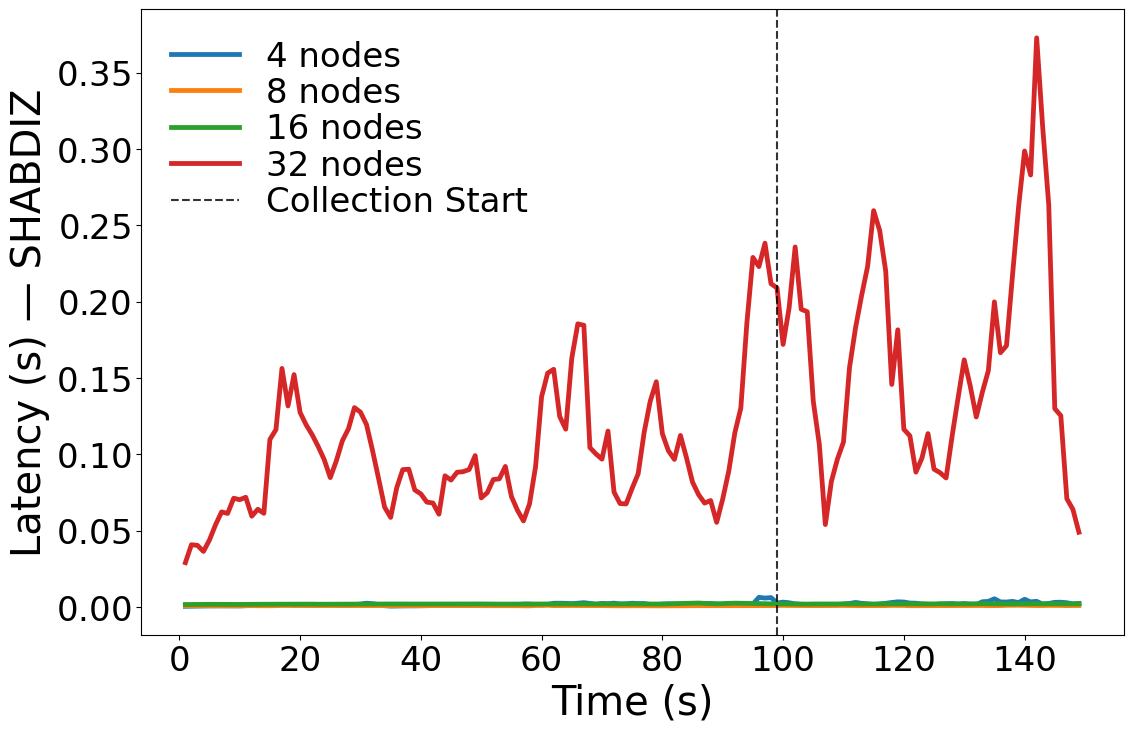

In [43]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.12,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



node_list = [4, 8, 16, 32]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index[:150],
        throughput_ma.values[:150],
        "-",
        label=f"{node_list[i]} nodes"
    )

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — SHABDIZ")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/collect_vs_nodes_thput.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index[:150],
        latency_ma.values[:150],
        "-",
        label=f"{node_list[i]} nodes"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — SHABDIZ")
# plt.title("Proposal to Commit Latency (During Collection)")


plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)

plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/collect_vs_nodes_lat.pdf", dpi=150)
plt.show()


Processing: ../work/experiments/stellar-core/collection_5_rounds_16_v2/tsm-sc-001/node2/stellar-core.log
Proposals parsed: 43016
Commits parsed:   43174
COLLECT views:    5


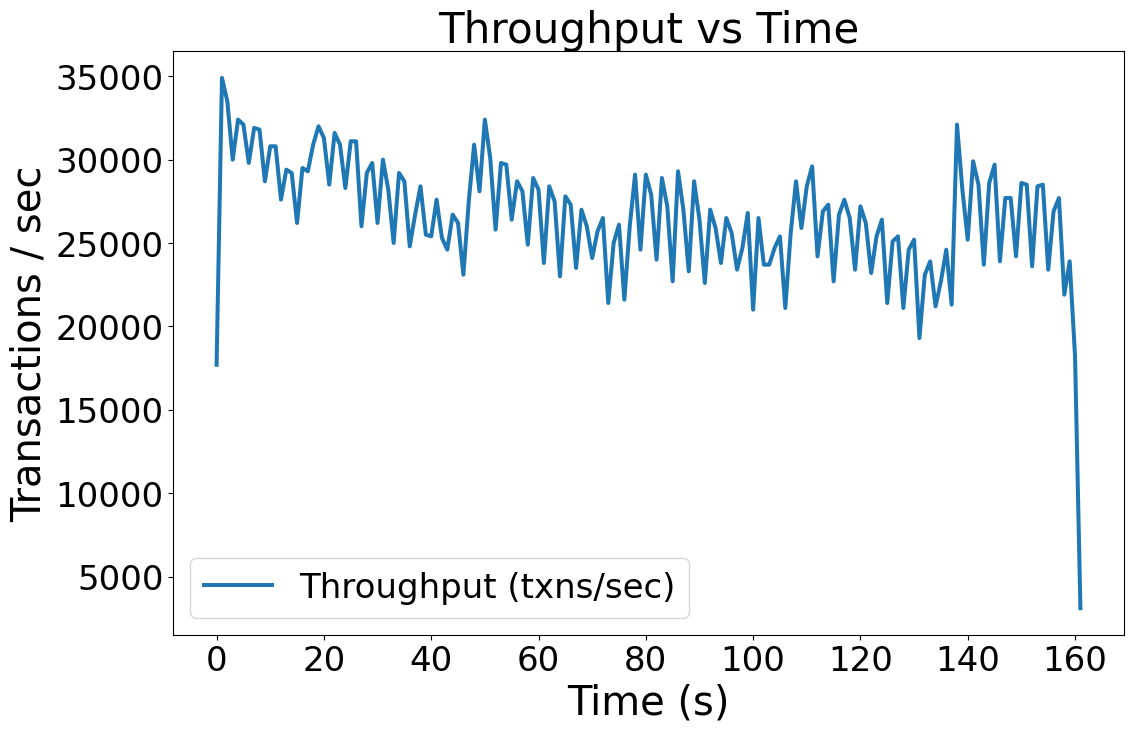

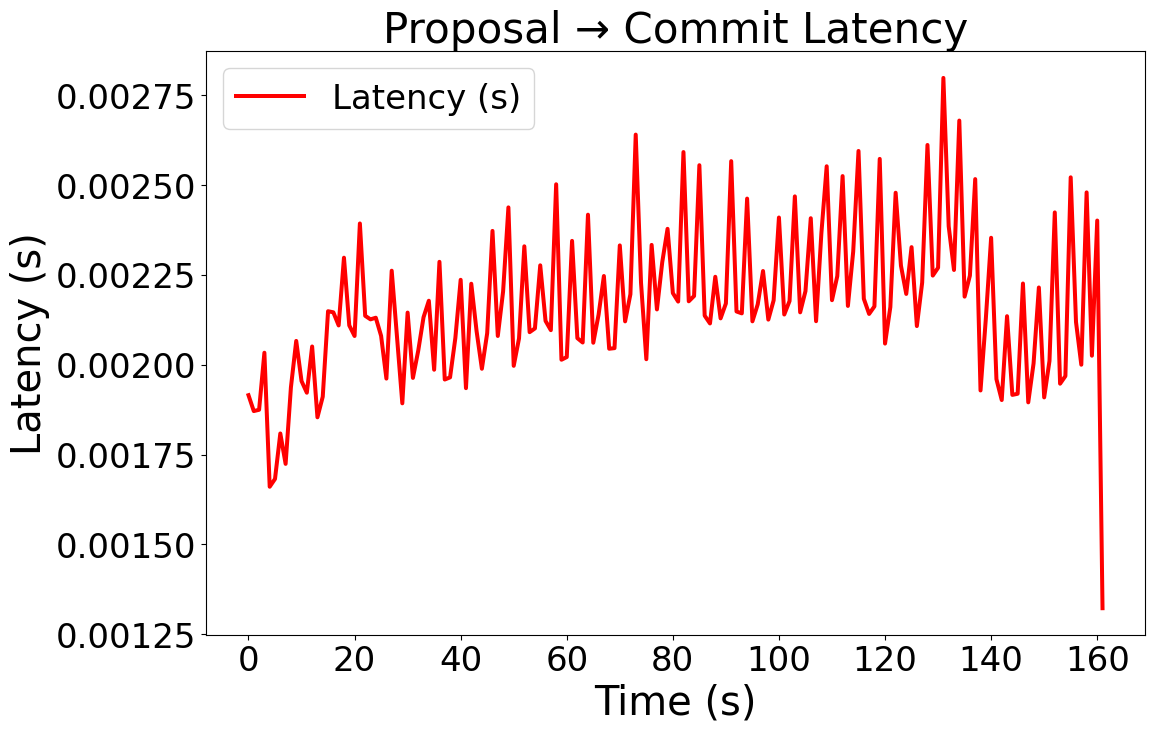

Average Throughput: 25353.333333333332
Average Latency: 0.002282076257682393
Processing: ../work/experiments/stellar-core/collection_50_rounds_16_v2/tsm-sc-001/node2/stellar-core.log
Proposals parsed: 45050
Commits parsed:   45120
COLLECT views:    50


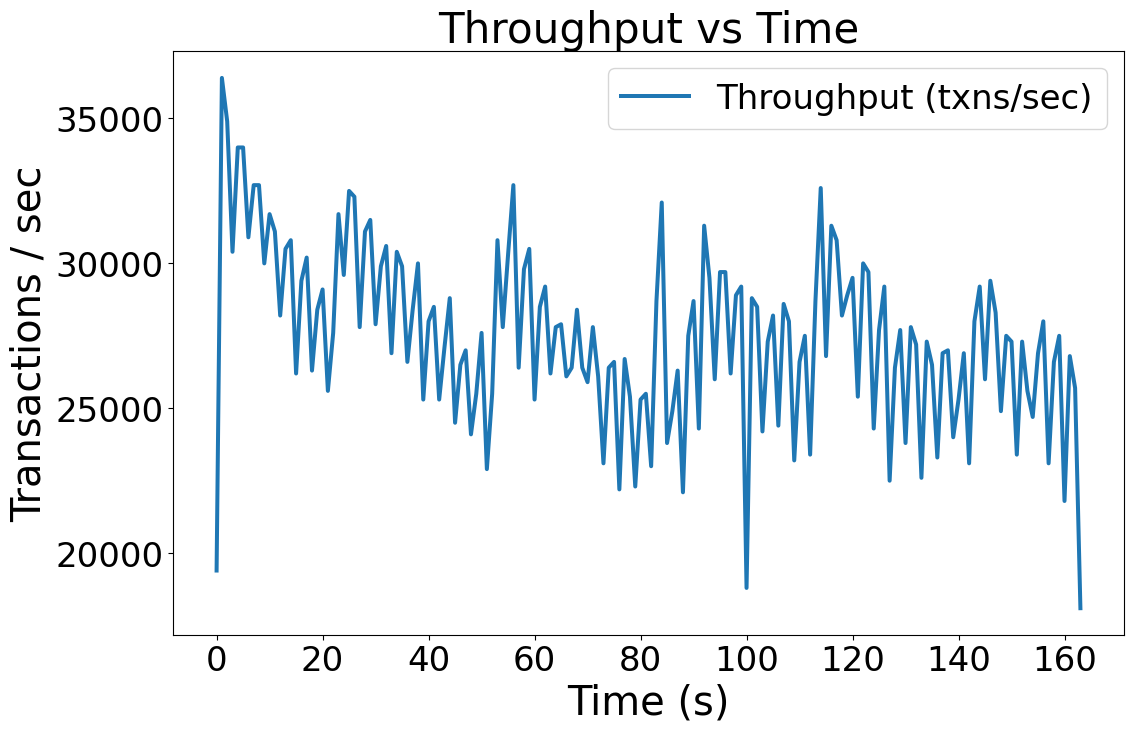

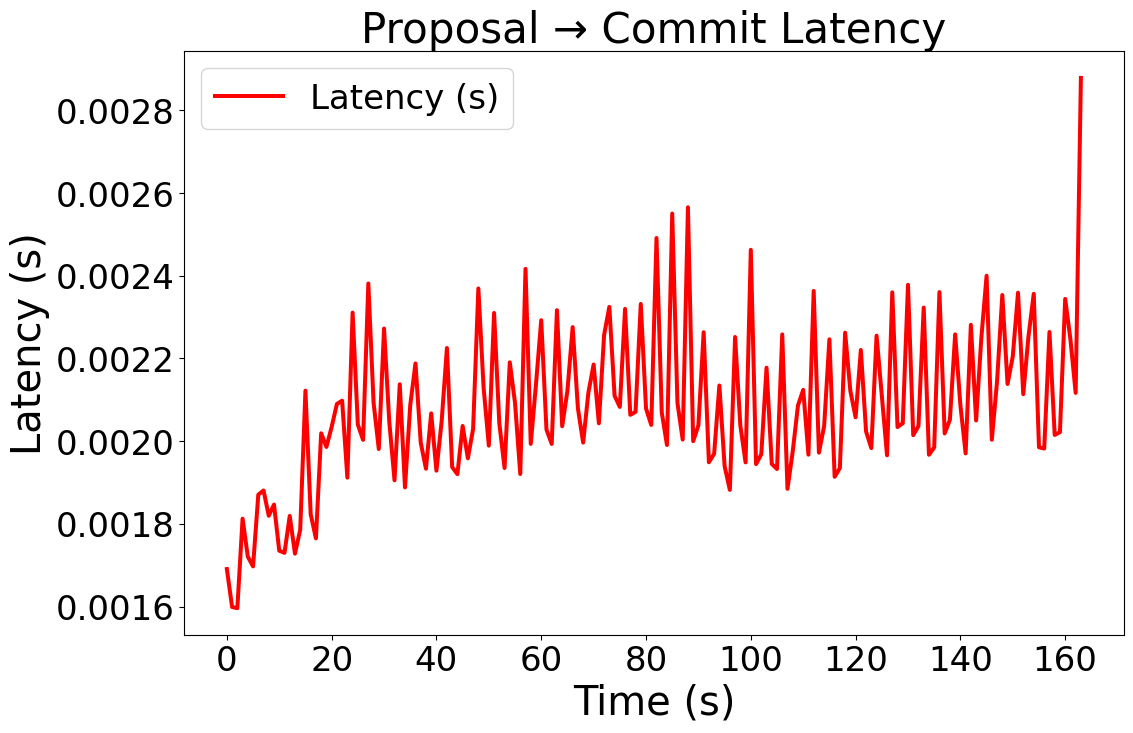

Average Throughput: 26848.333333333332
Average Latency: 0.002110999354166159
Processing: ../work/experiments/stellar-core/collection_500_rounds_16_v2/tsm-sc-001/node2/stellar-core.log
Proposals parsed: 41938
Commits parsed:   42050
COLLECT views:    500


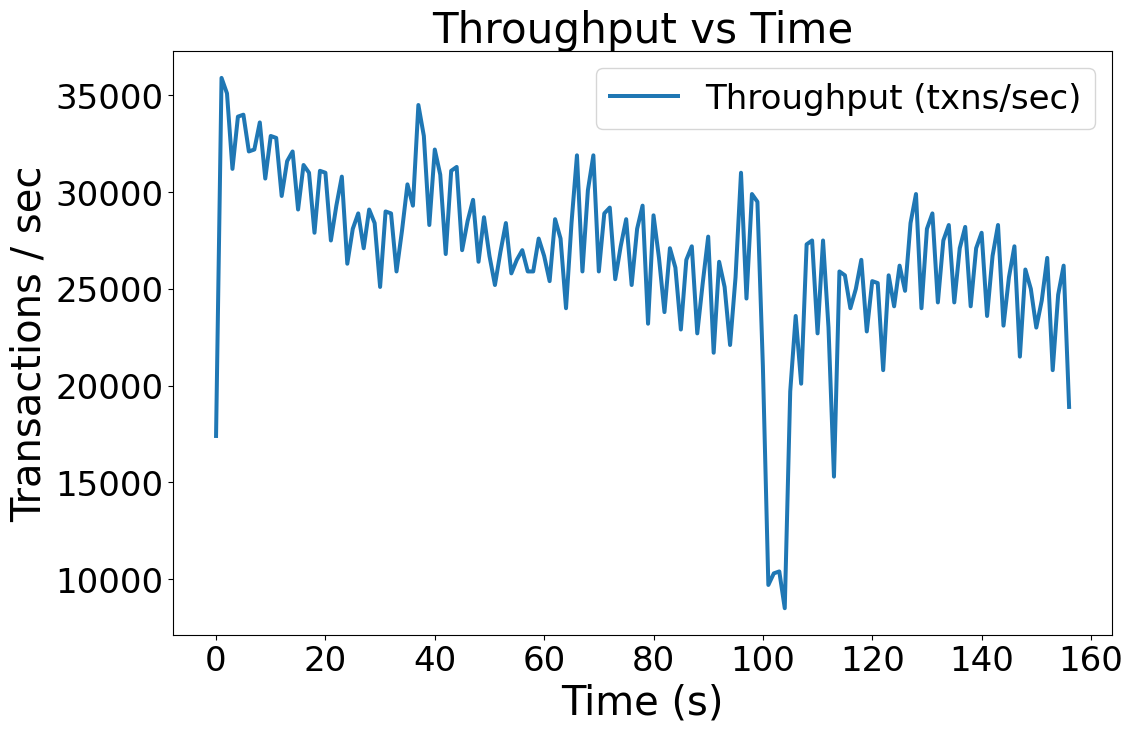

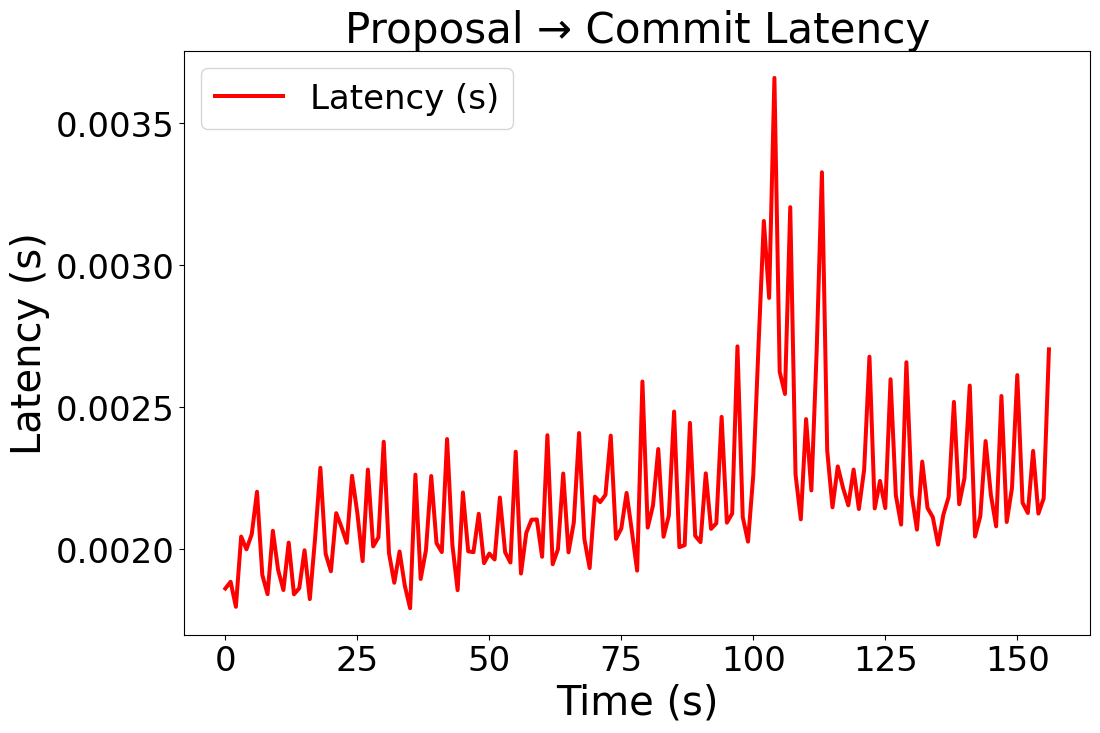

Average Throughput: 24473.333333333332
Average Latency: 0.002328918645803567


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_5_rounds_16_v2/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_50_rounds_16_v2/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_500_rounds_16_v2/tsm-sc-001/node2/stellar-core.log']



throughput_list = []
latency_list = []

# -----------------------------
# Regex patterns
# -----------------------------

# ALL ways a proposal can appear
propose_patterns = [
    re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    ),
    re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Leader proposing block (\w+) in view (\d+)"
    ),
    re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"CUSTOM_READY: Leader proposing block (\w+) in view (\d+)"
    ),
]

# Commit log
commit_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Committed block (\w+) at view (\d+) with (\d+) transactions"
)

# COLLECT views
collect_pattern = re.compile(r"Received COLLECT for view (\d+)")

# -----------------------------
# Parse logs
# -----------------------------
for log_file in log_file_list:
    print(f"Processing: {log_file}")

    propose_times = {}      # (block, view) -> earliest proposal time
    commit_times = {}       # (block, view) -> commit time
    batch_sizes = {}        # (block, view) -> txn count
    collect_views = set()   # views where COLLECT happened

    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            m = collect_pattern.search(line)
            if m:
                collect_views.add(int(m.group(1)))

            # Match ALL proposal forms
            for pat in propose_patterns:
                pm = pat.search(line)
                if pm:
                    ts = datetime.strptime(
                        pm.group(1), "%Y-%m-%dT%H:%M:%S.%f"
                    )
                    block = pm.group(2)
                    view = int(pm.group(3))
                    key = (block, view)

                    # Keep EARLIEST proposal time
                    if key not in propose_times or ts < propose_times[key]:
                        propose_times[key] = ts

            # Match COMMIT
            cm = commit_pattern.search(line)
            if cm:
                ts = datetime.strptime(
                    cm.group(1), "%Y-%m-%dT%H:%M:%S.%f"
                )
                block = cm.group(2)
                view = int(cm.group(3))
                batch = int(cm.group(4))

                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch

    print(f"Proposals parsed: {len(propose_times)}")
    print(f"Commits parsed:   {len(commit_times)}")
    print(f"COLLECT views:    {len(collect_views)}")

    # -----------------------------
    # Build latency + throughput data
    # -----------------------------
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []

    for key, ctime in commit_times.items():
        block, view = key

        # OPTIONAL: exclude COLLECT rounds entirely
        # if view in collect_views:
        #     continue

        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch = batch_sizes[key]

            latencies.append({
                "commit_time": ctime,
                "latency": latency
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch)

    if not commit_timestamps:
        print("No valid commits found.")
        continue

    # -----------------------------
    # Normalize time
    # -----------------------------
    start_time = min(commit_timestamps + list(propose_times.values()))

    # -----------------------------
    # Throughput (txns/sec)
    # -----------------------------
    commit_data = []
    for ts, txns in zip(commit_timestamps, commit_txn_counts):
        t = (ts - start_time).total_seconds()
        commit_data.append({"time": t, "txns": txns})

    df = pd.DataFrame(commit_data)
    df["time_round"] = df["time"].round().astype(int)

    throughput = df.groupby("time_round")["txns"].sum()

    full_index = np.arange(
        int(throughput.index.min()),
        int(throughput.index.max()) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)

    # -----------------------------
    # Latency (avg per second)
    # -----------------------------
    lat_df = pd.DataFrame(latencies)
    lat_df["time"] = lat_df["commit_time"].apply(
        lambda t: (t - start_time).total_seconds()
    )
    lat_df["time_round"] = lat_df["time"].round().astype(int)

    latency_series = lat_df.groupby("time_round")["latency"].mean()

    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)

    # -----------------------------
    # Plot Throughput
    # -----------------------------
    plt.figure(figsize=(12,8))
    plt.plot(
        throughput.index,
        throughput.values,
        label="Throughput (txns/sec)"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions / sec")
    plt.title("Throughput vs Time")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()

    # -----------------------------
    # Plot Latency
    # -----------------------------
    plt.figure(figsize=(12, 8))
    plt.plot(
        latency_series.index,
        latency_series.values,
        color="red",
        label="Latency (s)"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()

    print(
        "Average Throughput:",
        np.mean(throughput.values[-90:-30])
    )
    print(
        "Average Latency:",
        np.mean(latency_series.values[-90:-30])
    )

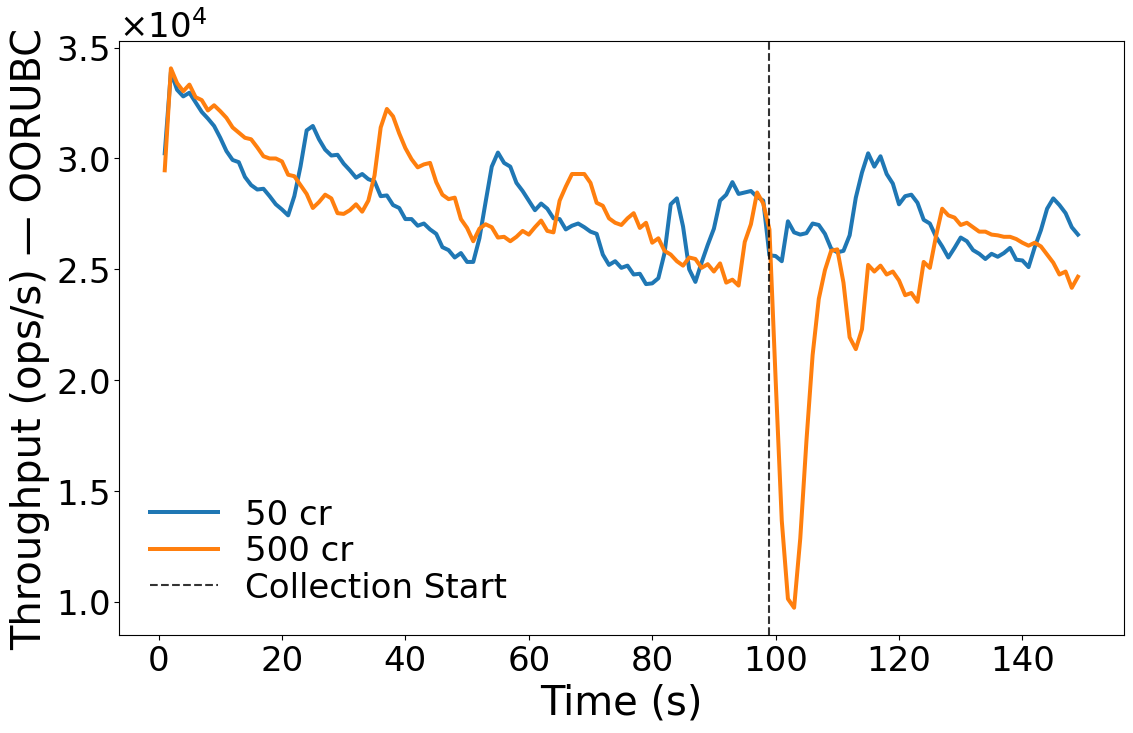

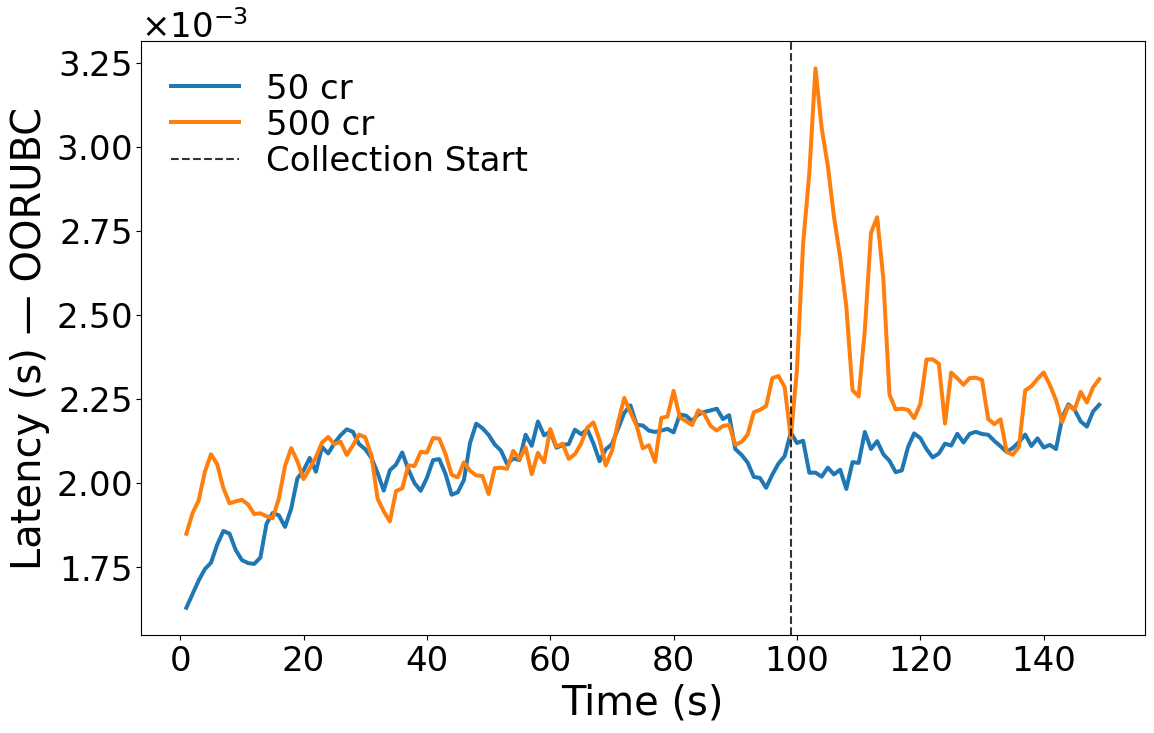

In [48]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.10,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



round_list = [50,500]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index[:150],
        throughput_ma.values[:150],
        "-",
        label=f"{round_list[i]} cr"
    )

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — OORUBC")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/thput_vs_collect_rounds.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index[:150],
        latency_ma.values[:150],
        "-",
        label=f"{round_list[i]} cr"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — OORUBC")
# plt.title("Proposal to Commit Latency (During Collection)")


plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)

plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/lat_vs_collect_rounds.pdf", dpi=150)
plt.show()


Processing: ../work/experiments/stellar-core/collection_100_rounds_16/tsm-sc-001/node2/stellar-core.log


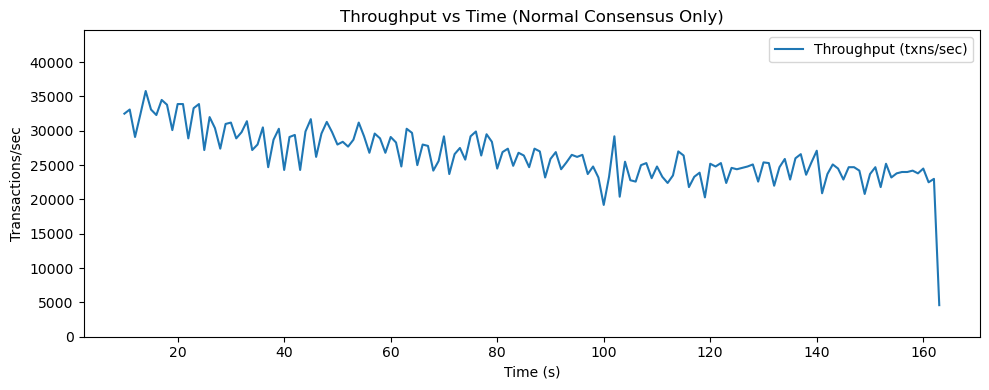

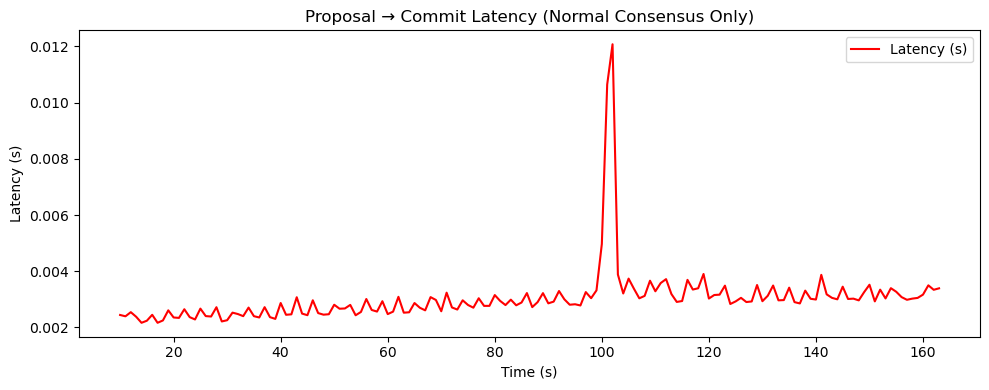

Average Throughput:  24936.666666666668
Average Latency:  0.0034319452034915457
Processing: ../work/experiments/stellar-core/collection_100_rounds_16_zone_0/tsm-sc-001/node2/stellar-core.log


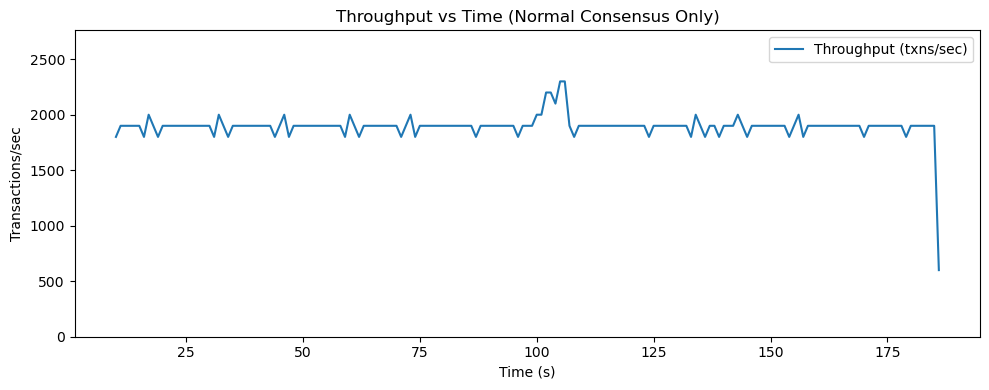

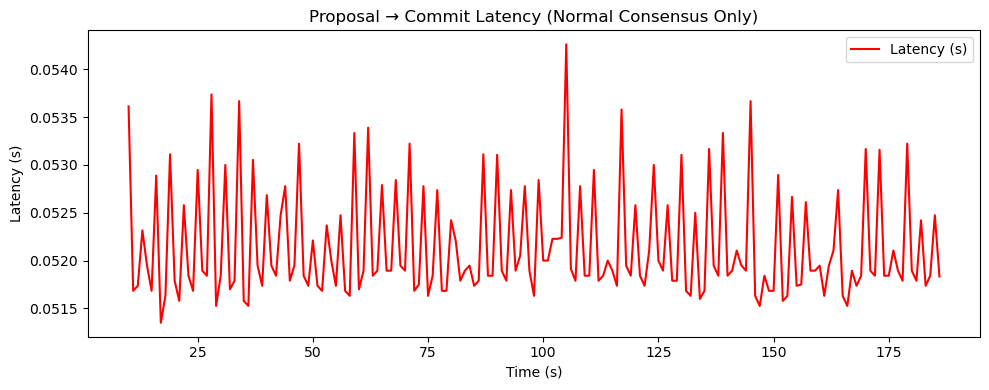

Average Throughput:  1923.3333333333333
Average Latency:  0.05214761020359419
Processing: ../work/experiments/stellar-core/collection_100_rounds_16_zone_1/tsm-sc-001/node2/stellar-core.log


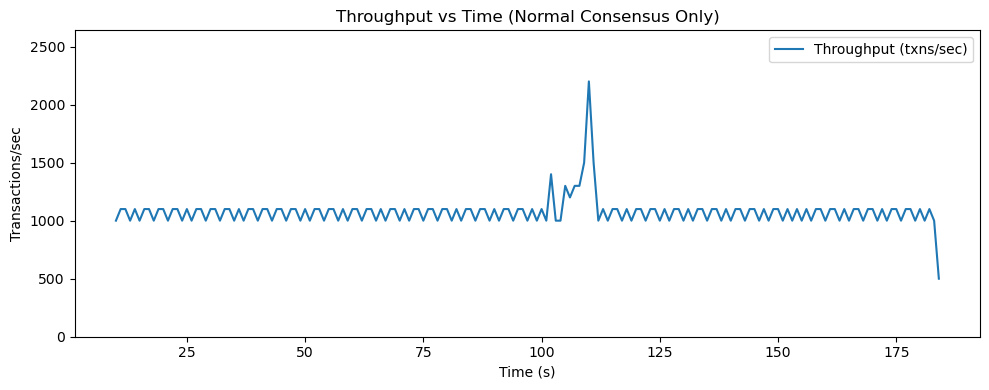

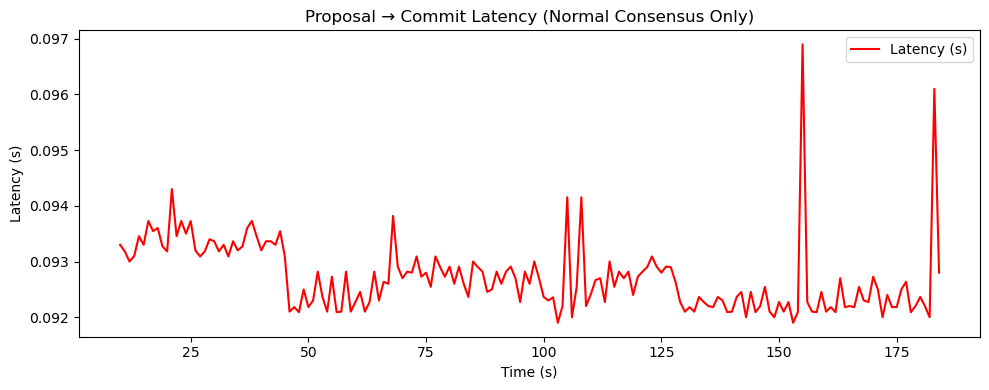

Average Throughput:  1111.6666666666667
Average Latency:  0.09248252969252967
Processing: ../work/experiments/stellar-core/collection_100_rounds_16_zone_2/tsm-sc-001/node2/stellar-core.log


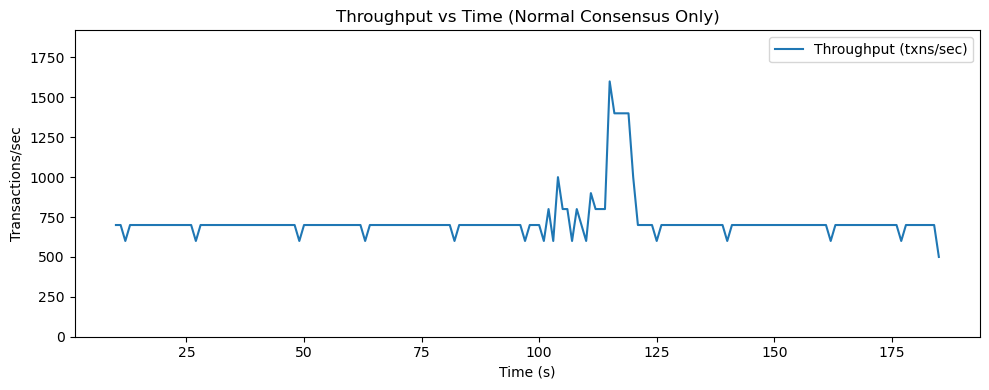

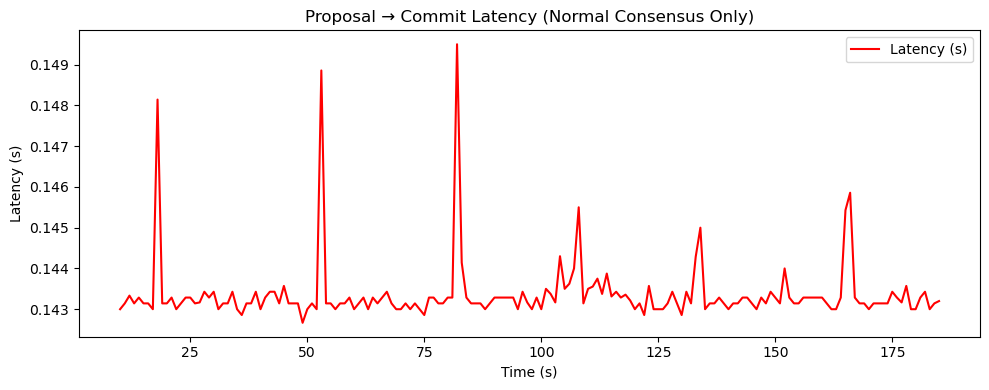

Average Throughput:  775.0
Average Latency:  0.14337026124338623
Processing: ../work/experiments/stellar-core/collection_100_rounds_16_zone_3/tsm-sc-001/node2/stellar-core.log


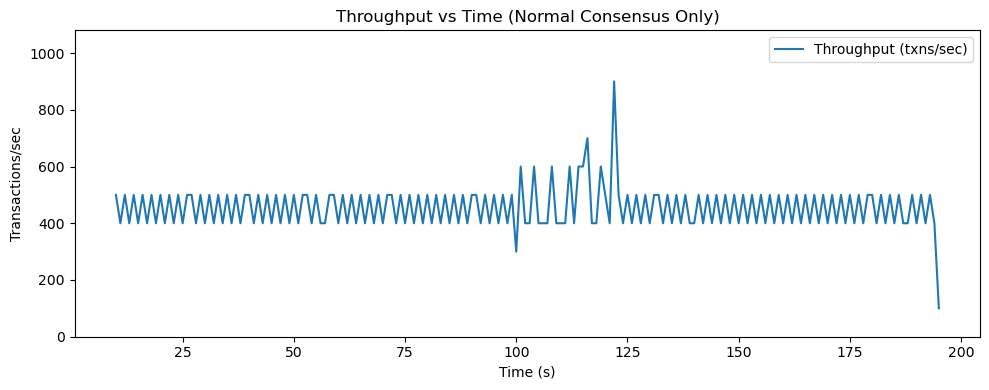

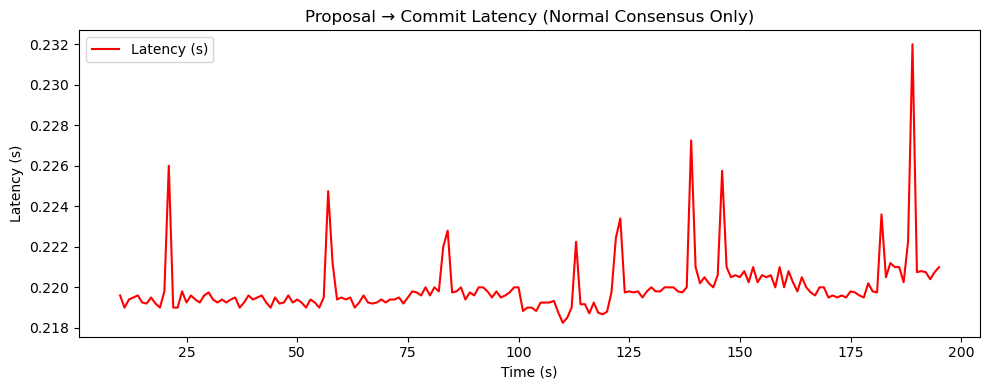

Average Throughput:  468.3333333333333
Average Latency:  0.2202448677248677


In [1]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import re
# from datetime import datetime
# import numpy as np

# # Path to your log file
# log_file_list = ['../work/experiments/stellar-core/collection_100_rounds_16/tsm-sc-001/node2/stellar-core.log',\
#                  '../work/experiments/stellar-core/collection_100_rounds_16_zone_0/tsm-sc-001/node2/stellar-core.log',\
#                 '../work/experiments/stellar-core/collection_100_rounds_16_zone_1/tsm-sc-001/node2/stellar-core.log',\
#                  '../work/experiments/stellar-core/collection_100_rounds_16_zone_2/tsm-sc-001/node2/stellar-core.log',\
#                 '../work/experiments/stellar-core/collection_100_rounds_16_zone_3/tsm-sc-001/node2/stellar-core.log']

# throughput_list = []
# latency_list = []

# for log_file in log_file_list:
#     print(f"Processing: {log_file}")
    
#     # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
#     propose_pattern = re.compile(
#         r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
#         r"Received PROPOSE block (\w+) at view (\d+)"
#     )
    
#     # ✅ FIXED: Extract batch size from commit logs
#     commit_pattern = re.compile(
#         r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
#         r"Committed block (\w+) at view (\d+) with (\d+) transactions"
#     )
    
#     # Track COLLECT views to exclude them
#     collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
#     # Dictionaries to hold times and batch sizes
#     propose_times = {}
#     commit_times = {}
#     batch_sizes = {}  # Store batch size per block
#     collect_views = set()
    
#     # Parse log file
#     with open(log_file) as f:
#         for line in f:
#             # Track COLLECT views
#             collect_match = collect_pattern.search(line)
#             if collect_match:
#                 view = int(collect_match.group(1))
#                 collect_views.add(view)
            
#             # Match PROPOSE
#             pmatch = propose_pattern.search(line)
#             if pmatch:
#                 ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
#                 block = pmatch.group(2)
#                 view = int(pmatch.group(3))
                
#                 # Store FIRST receipt time only
#                 if (block, view) not in propose_times:
#                     propose_times[(block, view)] = ts
            
#             # Match COMMIT
#             cmatch = commit_pattern.search(line)
#             if cmatch:
#                 ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
#                 block = cmatch.group(2)
#                 view = int(cmatch.group(3))
#                 batch_size = int(cmatch.group(4))  # Extract batch size
                
#                 commit_times[(block, view)] = ts
#                 batch_sizes[(block, view)] = batch_size  # Store batch size
    
#     # print(f"Total proposals received: {len(propose_times)}")
#     # print(f"Total commits: {len(commit_times)}")
#     # print(f"COLLECT views found: {len(collect_views)}")
    
#     # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
#     latencies = []
#     commit_timestamps = []
#     commit_txn_counts = []  # Track transactions per commit
    
#     for key, ctime in commit_times.items():
#         block, view = key
        
#         # ✅ Skip COLLECT rounds
#         # if view in collect_views:
#         #     continue
        
#         if key in propose_times:
#             latency = (ctime - propose_times[key]).total_seconds()
#             batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
#             latencies.append({
#                 "block": block,
#                 "view": view,
#                 "commit_time": ctime,
#                 "latency": latency,
#                 "batch_size": batch_size
#             })
#             commit_timestamps.append(ctime)
#             commit_txn_counts.append(batch_size)
    
#     if not commit_timestamps:
#         # print("No normal consensus commits found.")
#         # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
#         # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
#         continue
    
#     # print(f"Normal consensus commits: {len(latencies)}")
    
#     # Normalize times to seconds since start
#     start_time = min(commit_timestamps + list(propose_times.values()))
    
#     # Create dataframe with transaction counts
#     commit_data = []
#     for i, ts in enumerate(commit_timestamps):
#         time_sec = (ts - start_time).total_seconds()
#         commit_data.append({
#             "time_sec": time_sec,
#             "txn_count": commit_txn_counts[i]
#         })
    
#     df = pd.DataFrame(commit_data)
#     df.set_index("time_sec", inplace=True)
    
#     # ✅ Throughput = TRANSACTIONS per second
#     throughput = df.groupby(df.index.round())["txn_count"].sum()
    
#     # Fill missing integer seconds with zeros
#     full_index = np.arange(
#         int(np.floor(throughput.index.min())),
#         int(np.ceil(throughput.index.max())) + 1
#     )
#     throughput = throughput.reindex(full_index, fill_value=0)
    
#     # DataFrame for latencies
#     lat_df = pd.DataFrame(latencies)
#     lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
#     lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
#     # Average latency per second
#     latency_series = (
#         lat_df
#         .groupby("time_sec_round")["latency"]
#         .mean()
#     )
    
#     # Full integer time range
#     full_index = np.arange(
#         int(latency_series.index.min()),
#         int(latency_series.index.max()) + 1
#     )
    
#     # Fill missing seconds with 0 latency
#     latency_series = latency_series.reindex(full_index, fill_value=0)

#     throughput_list.append(throughput)
#     latency_list.append(latency_series)
    
#     # ---- Plot Throughput ----
#     plt.figure(figsize=(10, 4))
#     plt.plot(throughput.index[10:], throughput.values[10:], "-", label="Throughput (txns/sec)")
    
#     plt.xlabel("Time (s)")
#     plt.ylabel("Transactions/sec")
#     plt.ylim(0, throughput.values.max() * 1.2)
#     plt.title("Throughput vs Time (Normal Consensus Only)")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig("throughput.png", dpi=150)
#     plt.show()
    
#     # ---- Plot Latency ----
#     plt.figure(figsize=(10, 4))
#     plt.plot(latency_series.index[10:], latency_series.values[10:], "-", color="r", label="Latency (s)")
#     plt.xlabel("Time (s)")
#     plt.ylabel("Latency (s)")
#     plt.title("Proposal → Commit Latency (Normal Consensus Only)")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig("latency.png", dpi=150)
#     plt.show()
    
#     print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
#     print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

Processing: ../work/experiments/stellar-core/collection_100_rounds_16_zone_0_v2/tsm-sc-000/node1/stellar-core.log
Proposals parsed: 42688
Commits parsed:   42688
COLLECT views:    0


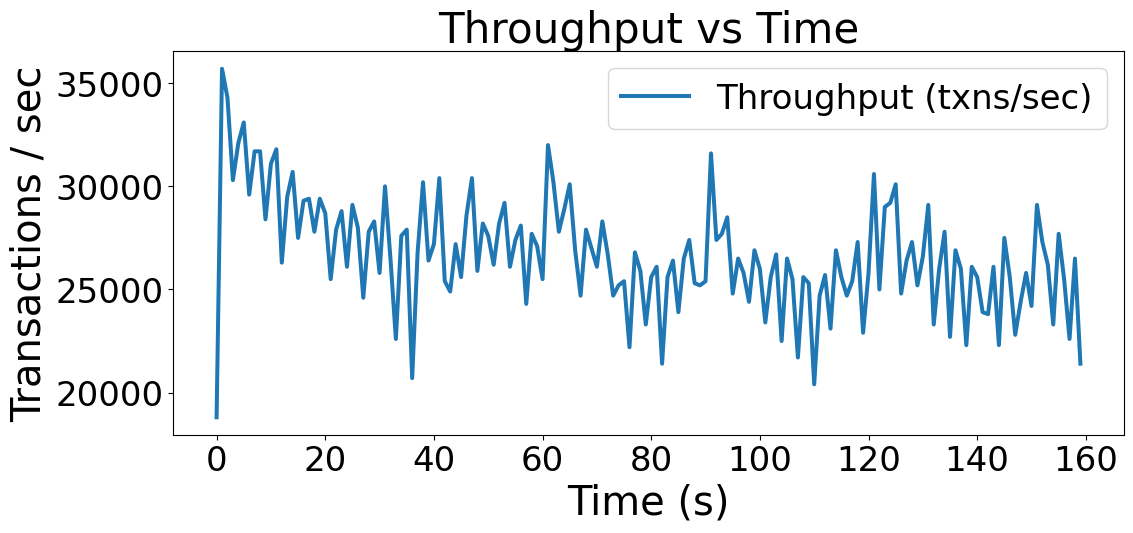

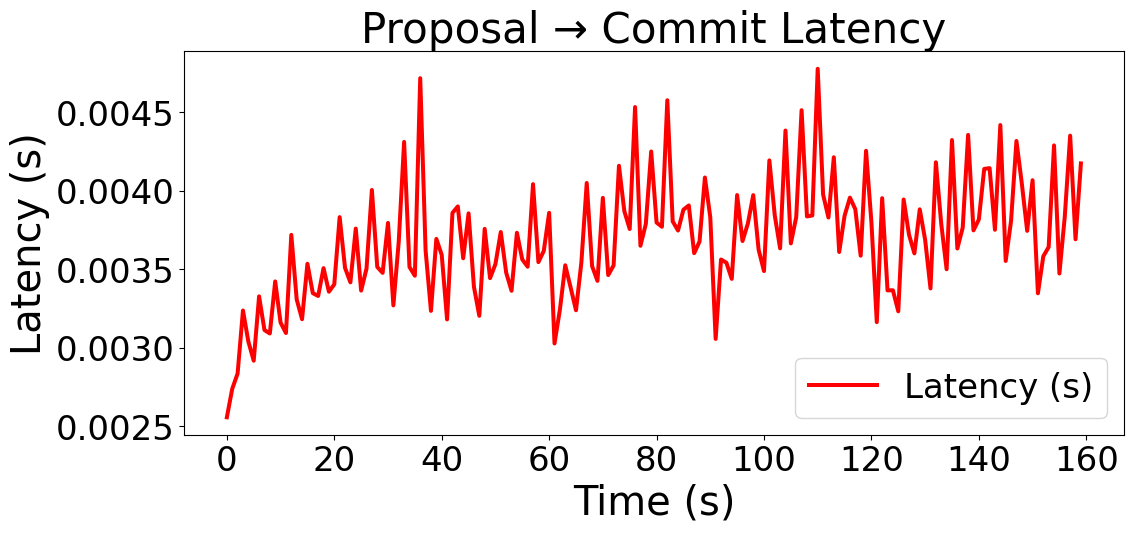

Average Throughput: 25765.0
Average Latency: 0.003823541269054881
Processing: ../work/experiments/stellar-core/collection_100_rounds_16_zone_1_v2/tsm-sc-000/node1/stellar-core.log
Proposals parsed: 1892
Commits parsed:   1892
COLLECT views:    0


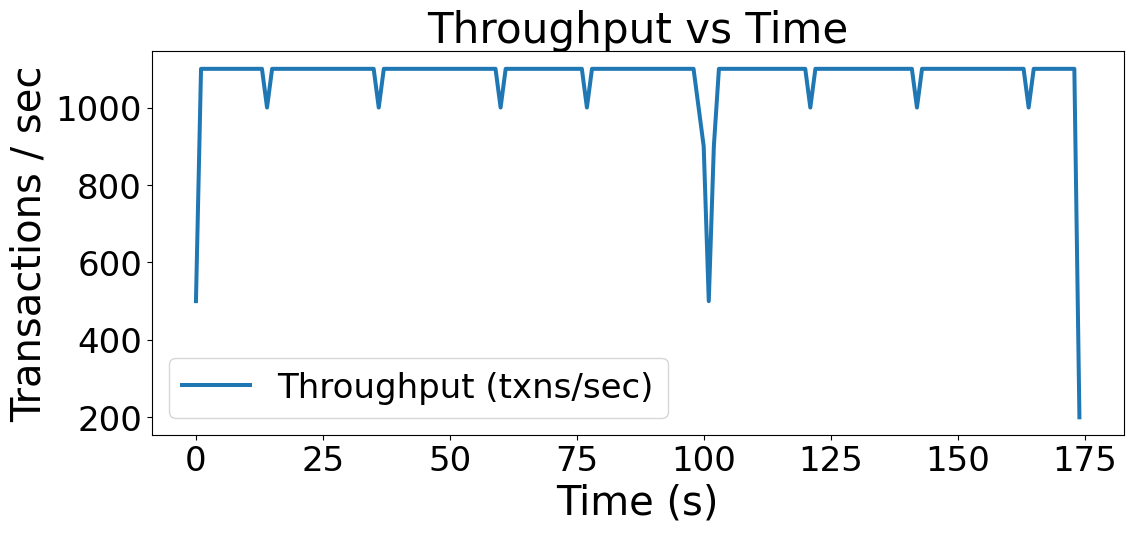

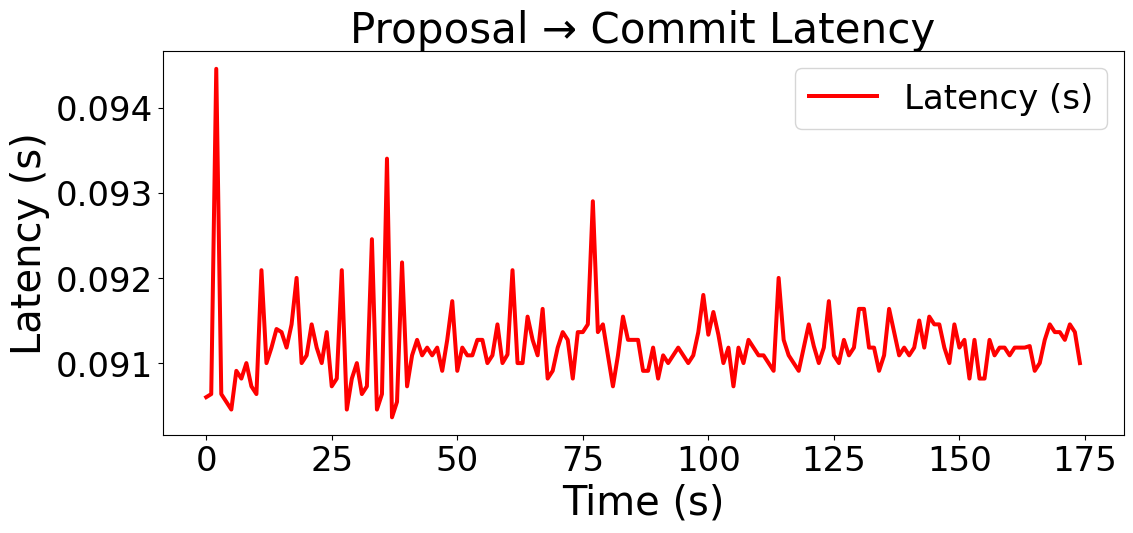

Average Throughput: 1078.3333333333333
Average Latency: 0.09120065656565654
Processing: ../work/experiments/stellar-core/collection_100_rounds_16_zone_2_v2/tsm-sc-000/node1/stellar-core.log
Proposals parsed: 721
Commits parsed:   720
COLLECT views:    0


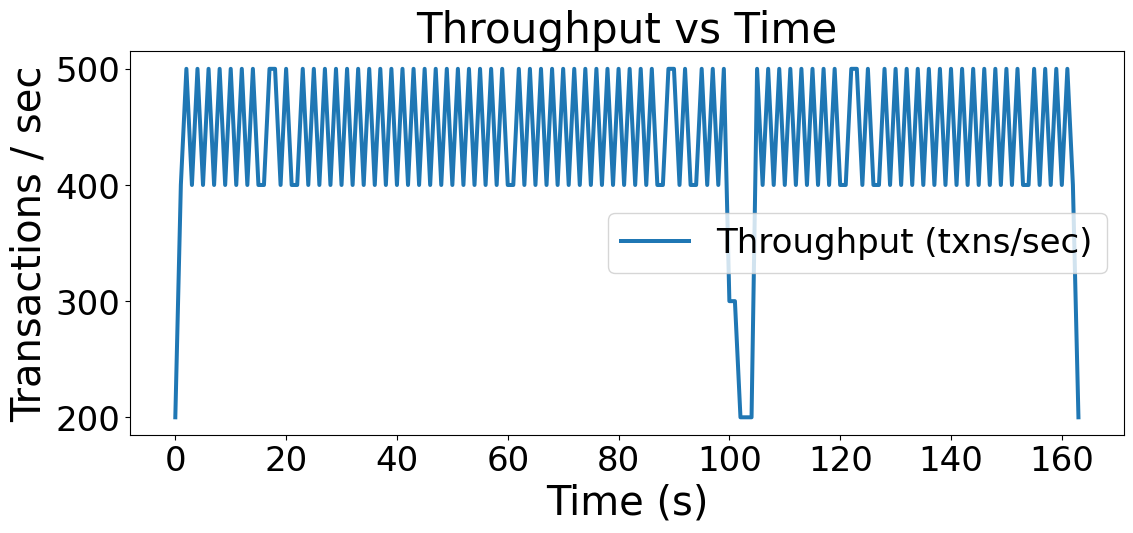

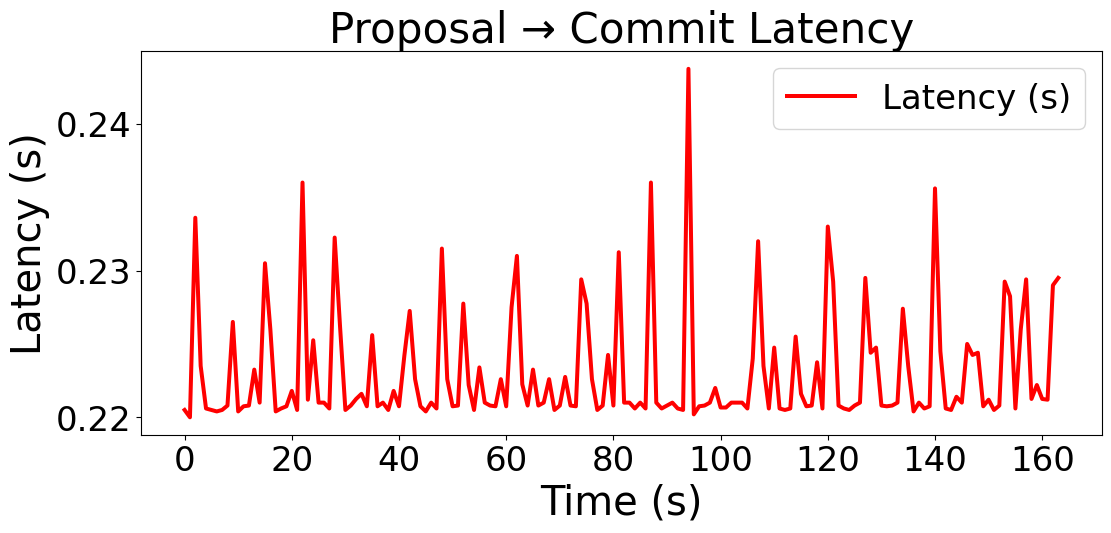

Average Throughput: 431.6666666666667
Average Latency: 0.22304972222222222


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# -----------------------------
# Log file(s)
# -----------------------------
log_file_list = [
    '../work/experiments/stellar-core/collection_100_rounds_16_zone_0_v2/tsm-sc-000/node1/stellar-core.log',\
    '../work/experiments/stellar-core/collection_100_rounds_16_zone_1_v2/tsm-sc-000/node1/stellar-core.log',\
    '../work/experiments/stellar-core/collection_100_rounds_16_zone_2_v2/tsm-sc-000/node1/stellar-core.log'
]

throughput_list = []
latency_list = []

# -----------------------------
# Regex patterns
# -----------------------------

# ALL ways a proposal can appear
propose_patterns = [
    re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    ),
    re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Leader proposing block (\w+) in view (\d+)"
    ),
    re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"CUSTOM_READY: Leader proposing block (\w+) in view (\d+)"
    ),
]

# Commit log
commit_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Committed block (\w+) at view (\d+) with (\d+) transactions"
)

# COLLECT views
collect_pattern = re.compile(r"Received COLLECT for view (\d+)")

# -----------------------------
# Parse logs
# -----------------------------
for log_file in log_file_list:
    print(f"Processing: {log_file}")

    propose_times = {}      # (block, view) -> earliest proposal time
    commit_times = {}       # (block, view) -> commit time
    batch_sizes = {}        # (block, view) -> txn count
    collect_views = set()   # views where COLLECT happened

    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            m = collect_pattern.search(line)
            if m:
                collect_views.add(int(m.group(1)))

            # Match ALL proposal forms
            for pat in propose_patterns:
                pm = pat.search(line)
                if pm:
                    ts = datetime.strptime(
                        pm.group(1), "%Y-%m-%dT%H:%M:%S.%f"
                    )
                    block = pm.group(2)
                    view = int(pm.group(3))
                    key = (block, view)

                    # Keep EARLIEST proposal time
                    if key not in propose_times or ts < propose_times[key]:
                        propose_times[key] = ts

            # Match COMMIT
            cm = commit_pattern.search(line)
            if cm:
                ts = datetime.strptime(
                    cm.group(1), "%Y-%m-%dT%H:%M:%S.%f"
                )
                block = cm.group(2)
                view = int(cm.group(3))
                batch = int(cm.group(4))

                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch

    print(f"Proposals parsed: {len(propose_times)}")
    print(f"Commits parsed:   {len(commit_times)}")
    print(f"COLLECT views:    {len(collect_views)}")

    # -----------------------------
    # Build latency + throughput data
    # -----------------------------
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []

    for key, ctime in commit_times.items():
        block, view = key

        # OPTIONAL: exclude COLLECT rounds entirely
        # if view in collect_views:
        #     continue

        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch = batch_sizes[key]

            latencies.append({
                "commit_time": ctime,
                "latency": latency
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch)

    if not commit_timestamps:
        print("No valid commits found.")
        continue

    # -----------------------------
    # Normalize time
    # -----------------------------
    start_time = min(commit_timestamps + list(propose_times.values()))

    # -----------------------------
    # Throughput (txns/sec)
    # -----------------------------
    commit_data = []
    for ts, txns in zip(commit_timestamps, commit_txn_counts):
        t = (ts - start_time).total_seconds()
        commit_data.append({"time": t, "txns": txns})

    df = pd.DataFrame(commit_data)
    df["time_round"] = df["time"].round().astype(int)

    throughput = df.groupby("time_round")["txns"].sum()

    full_index = np.arange(
        int(throughput.index.min()),
        int(throughput.index.max()) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)

    # -----------------------------
    # Latency (avg per second)
    # -----------------------------
    lat_df = pd.DataFrame(latencies)
    lat_df["time"] = lat_df["commit_time"].apply(
        lambda t: (t - start_time).total_seconds()
    )
    lat_df["time_round"] = lat_df["time"].round().astype(int)

    latency_series = lat_df.groupby("time_round")["latency"].mean()

    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)

    # -----------------------------
    # Plot Throughput
    # -----------------------------
    plt.figure(figsize=(12, 6))
    plt.plot(
        throughput.index,
        throughput.values,
        label="Throughput (txns/sec)"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions / sec")
    plt.title("Throughput vs Time")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()

    # -----------------------------
    # Plot Latency
    # -----------------------------
    plt.figure(figsize=(12, 6))
    plt.plot(
        latency_series.index,
        latency_series.values,
        color="red",
        label="Latency (s)"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()

    print(
        "Average Throughput:",
        np.mean(throughput.values[-90:-30])
    )
    print(
        "Average Latency:",
        np.mean(latency_series.values[-90:-30])
    )


26778.747203579416
1087.248322147651
441.38702460850106


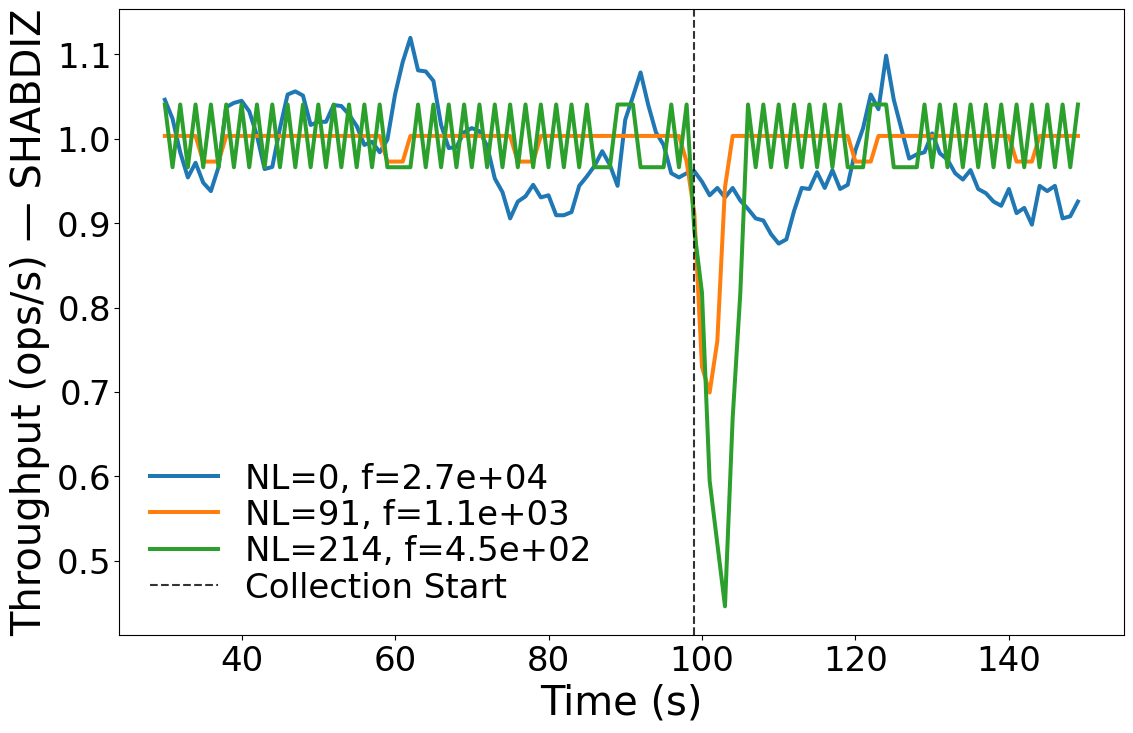

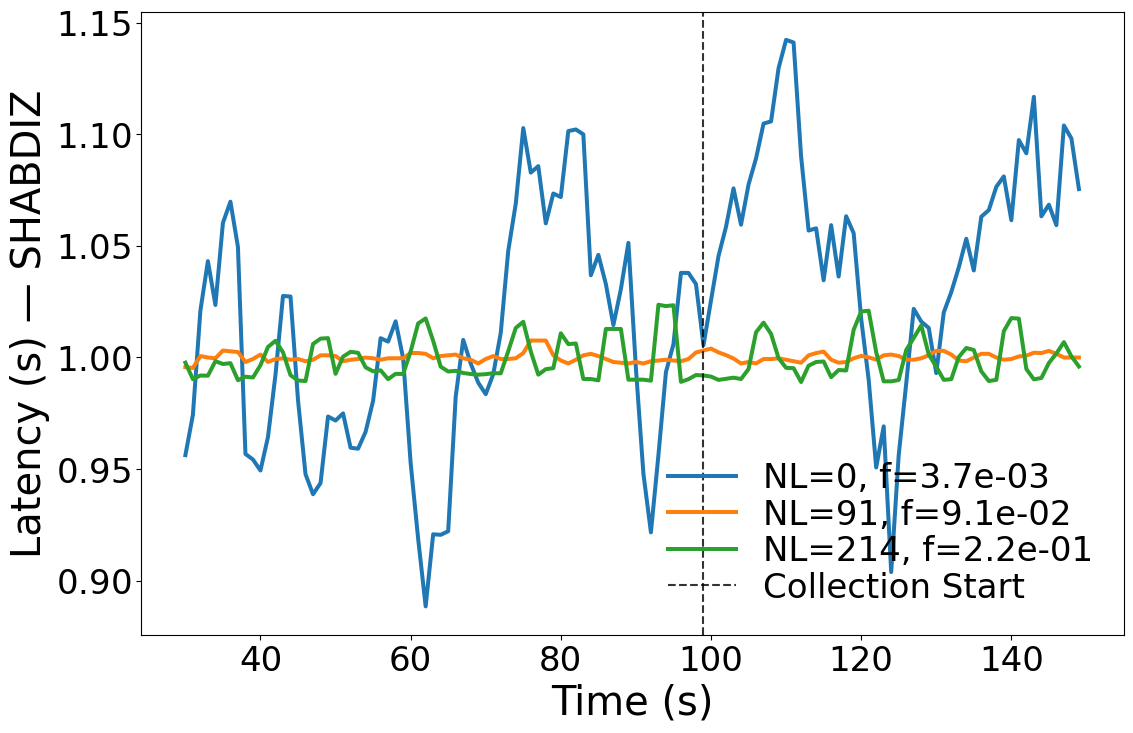

In [35]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.10,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



nl_list = [0,91,214]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    print(np.nanmean(np.array(throughput_ma.values[:150])))
    val = np.nanmean(throughput_ma.values[40:95])

    
    plt.plot(
        throughput_ma.index[30:150],
        throughput_ma.values[30:150]/np.nanmean(np.array(throughput_ma.values[40:95])),
        "-",
        label=f"NL={nl_list[i]}, f={val:.1e}"
    )


plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — SHABDIZ")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(x=99, color = 'black', linewidth=1.5, linestyle="--",alpha=0.8, label = 'Collection Start')


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/thput_vs_NL.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    val = np.nanmean(latency_ma.values[40:95])

    plt.plot(
        latency_ma.index[30:150],
        latency_ma.values[30:150]/ np.nanmean(np.array(latency_ma.values[40:95])),
        "-",
        label=f"NL={nl_list[i]}, f={val:.1e}"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — SHABDIZ")
# plt.title("Proposal to Commit Latency (During Collection)")


plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start')

plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/lat_vs_NL.pdf", dpi=150)
plt.show()


27226.0
1897.3333333333333
1078.6666666666667
724.0
457.3333333333333


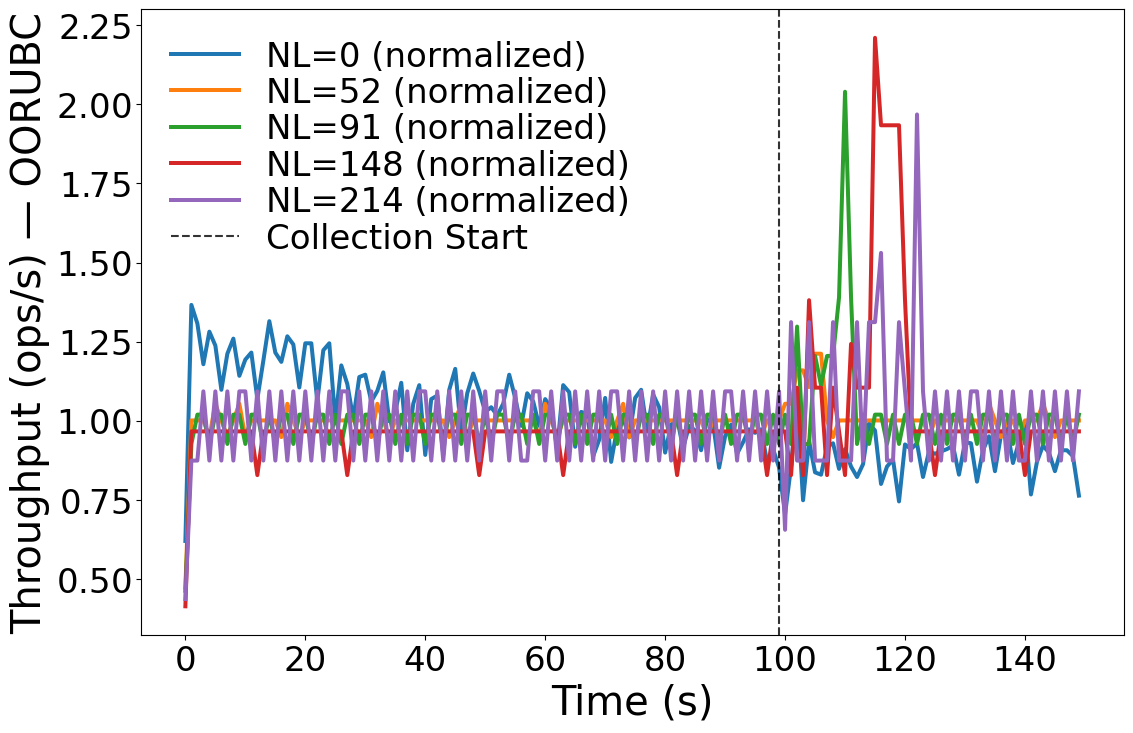

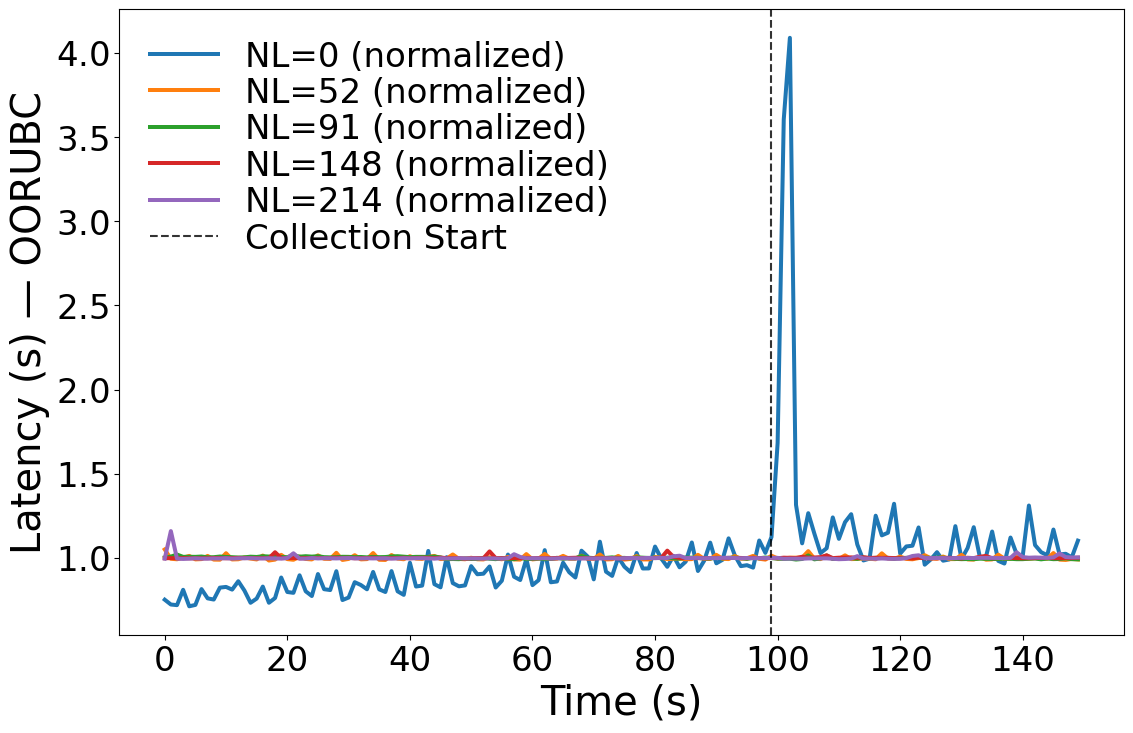

In [6]:
# import pylab as pl
# import matplotlib as mpl
# from matplotlib.ticker import ScalarFormatter
# import numpy as np
# from matplotlib.ticker import FuncFormatter


# def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
#     """
#     Returns a dict of font sizes scaled to figure size.
#     """
#     height_pt = fig_height_in * 72  # 1 inch = 72 pt

#     base = 0.05 * height_pt   # 2.5% of figure height

#     return {
#         "font.size": base,
#         "axes.labelsize": base * 1.0,
#         "xtick.labelsize": base * 0.85,
#         "ytick.labelsize": base * 0.85,
#         "legend.fontsize": base * 0.85,
#         "axes.titlesize": base * 1.05,
#         "lines.markersize": base * 0.55,
#         "lines.linewidth": base * 0.10,
#     }


# fig_w, fig_h = 12, 8  # inches

# mpl.rcParams.update(
#     font_scale_from_figsize(fig_w, fig_h)
# )



# nl_list = [0,52,91,148, 214]
# window = 1  # moving average window size

# # ---- Plot Throughput ----
# plt.figure(figsize=(12, 8))
# for i, throughput in enumerate(throughput_list):
#     throughput_ma = throughput.rolling(window=window, center=True).mean()
#     print(np.nanmean(np.array(throughput_ma.values[:150])))
#     plt.plot(
#         throughput_ma.index[:150],
#         throughput_ma.values[:150]/ np.nanmean(np.array(throughput_ma.values[:150])),
#         "-",
#         label=f"NL={nl_list[i]} (normalized)"
#     )

# plt.xlabel("Time (s)")
# plt.ylabel("Throughput (ops/s) — OORUBC")
# # plt.title("Throughput vs Time (During Collection)")

# plt.axvline(
#     x=99, color = 'black',linewidth=1.5,
#     linestyle="--",
#     alpha=0.8, label = 'Collection Start'
# )


# plt.legend(labelspacing=0.1,frameon=False)


# formatter1 = ScalarFormatter(useMathText=True)
# formatter1.set_powerlimits((-2, 2))
# plt.gca().yaxis.set_major_formatter(formatter1)



# plt.tight_layout()
# plt.savefig("../work/Stellar2/Figures/thput_vs_NL.pdf", dpi=150)
# plt.show()


# # ---- Plot Latency ----
# plt.figure(figsize=(12, 8))
# for i, latency_series in enumerate(latency_list):
#     latency_ma = latency_series.rolling(window=window, center=True).mean()
#     plt.plot(
#         latency_ma.index[:150],
#         latency_ma.values[:150]/np.nanmean(np.array(latency_ma.values[:150])),
#         "-",
#         label=f"NL={nl_list[i]} (normalized)"
#     )
# # plt.ylim(0,0.05)
# plt.xlabel("Time (s)")
# plt.ylabel("Latency (s) — OORUBC")
# # plt.title("Proposal to Commit Latency (During Collection)")


# plt.axvline(
#     x=99, color = 'black',linewidth=1.5,
#     linestyle="--",
#     alpha=0.8, label = 'Collection Start'
# )

# plt.legend(labelspacing=0.1, frameon=False)
# formatter1 = ScalarFormatter(useMathText=True)
# formatter1.set_powerlimits((-2, 2))
# plt.gca().yaxis.set_major_formatter(formatter1)

# plt.tight_layout()
# plt.savefig("../work/Stellar2/Figures/lat_vs_NL.pdf", dpi=150)
# plt.show()


# Memory Plots

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

log_file_list = [
    '../work/experiments/stellar-core/memory_4_no_cleanup/tsm-sc-001/node2/stellar-core.log',
    '../work/experiments/stellar-core/memory_4_regular_cleanup/tsm-sc-001/node2/stellar-core.log',
    '../work/experiments/stellar-core/memory_4_test/tsm-sc-001/node2/stellar-core.log'
]

memory_series_list = []
elements_series_list = []

# Updated regex: RSS + element count
memory_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*MEMORY RSS:\s+(\d+)\s+MB,\s+number of elements:\s+(\d+)"
)

for log_file in log_file_list:
    print(f"Processing: {log_file}")

    timestamps = []
    memory_mb = []
    elements = []

    with open(log_file) as f:
        for line in f:
            match = memory_pattern.search(line)
            if match:
                ts = datetime.strptime(match.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                mem = int(match.group(2))
                elems = int(match.group(3))

                timestamps.append(ts)
                memory_mb.append(mem)
                elements.append(elems)

    if not timestamps:
        print("⚠️ No memory entries found")
        continue

    # Normalize time
    start_time = min(timestamps)
    time_sec = [(t - start_time).total_seconds() for t in timestamps]

    df = pd.DataFrame({
        "time_sec": time_sec,
        "memory_mb": memory_mb,
        "elements": elements
    }).set_index("time_sec")

    # Aggregate per second
    df = df.groupby(df.index.round()).mean()

    # Fill missing seconds
    full_index = np.arange(
        int(np.floor(df.index.min())),
        int(np.ceil(df.index.max())) + 1
    )
    df = df.reindex(full_index).interpolate()

    memory_series_list.append(df["memory_mb"])
    elements_series_list.append(df["elements"])

    print("Average RSS (MB):", np.mean(df["memory_mb"].values[-90:-30]))


Processing: ../work/experiments/stellar-core/memory_4_no_cleanup/tsm-sc-001/node2/stellar-core.log
Average RSS (MB): 220.4548003745569
Processing: ../work/experiments/stellar-core/memory_4_regular_cleanup/tsm-sc-001/node2/stellar-core.log
Average RSS (MB): 75.59588961150175
Processing: ../work/experiments/stellar-core/memory_4_test/tsm-sc-001/node2/stellar-core.log
Average RSS (MB): 79.02222575204193


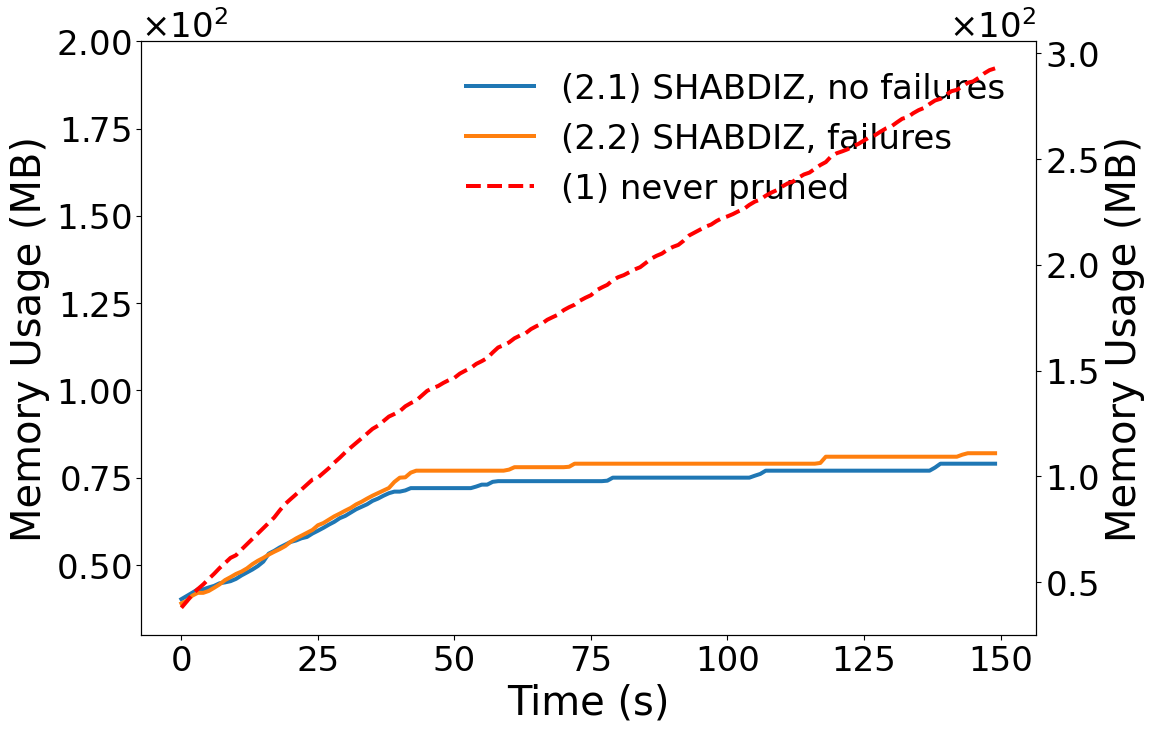

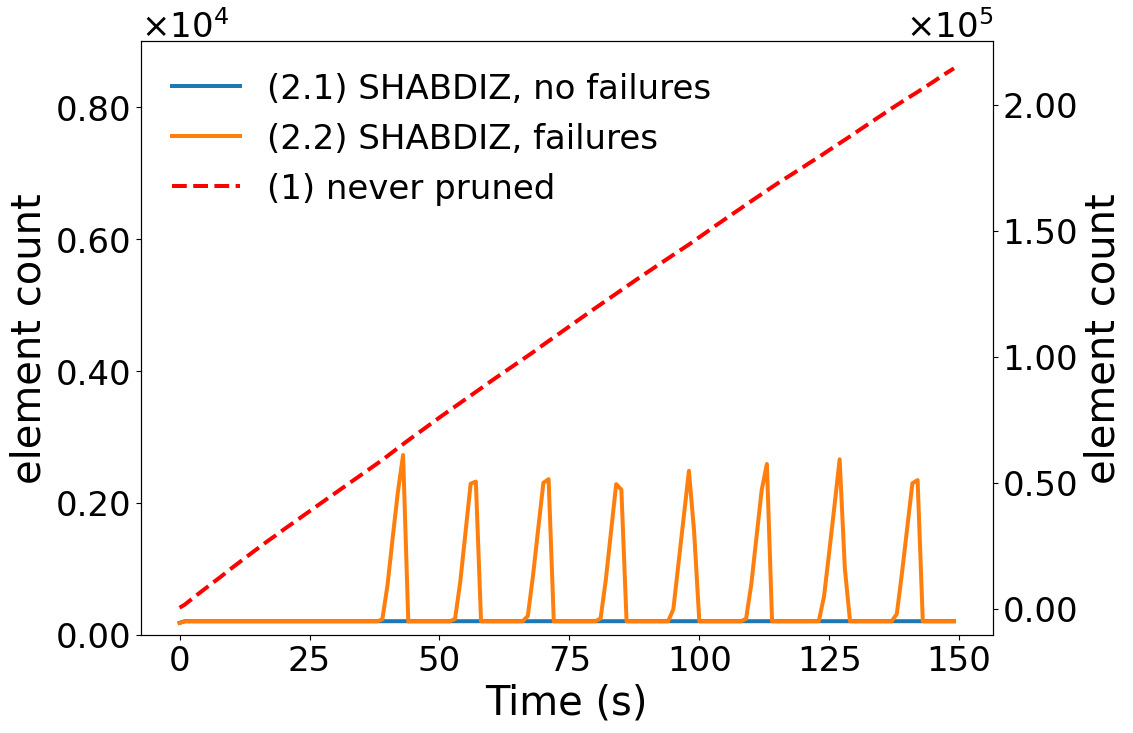

In [18]:
    


import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt
    base = 0.05 * height_pt

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.10,
    }


# -----------------------------
# Global style
# -----------------------------
fig_w, fig_h = 12, 8  # inches
mpl.rcParams.update(font_scale_from_figsize(fig_w, fig_h))

label_list = ['(1) never pruned', '(2.1) SHABDIZ, no failures', '(2.2) SHABDIZ, failures']
# label_list = ['cleanup',  'regular failure injection']

window = 1  # moving average window

# -----------------------------
# Plot Memory
# -----------------------------
plt.figure(figsize=(12, 8))
ax = plt.gca()
ax_r = ax.twinx()

for i, mem_series in enumerate(memory_series_list):
    mem_ma = mem_series.rolling(window=window, center=True).mean()

    if i == 0:
        ax_r.plot(
            mem_ma.index[:150],
            mem_ma.values[:150],
            label=label_list[i],
            linestyle="--", color ='red'
        )
    else:
        ax.plot(
            mem_ma.index[:150],
            mem_ma.values[:150],
            "-",
            label=label_list[i]
        )

ax.set_ylim(30,200)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Memory Usage (MB)")
ax_r.set_ylabel("Memory Usage (MB)")

# Combine legends
lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, frameon=False)

# Formatting
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))
ax.yaxis.set_major_formatter(formatter)
ax_r.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/memory.pdf", dpi=150)
plt.show()


from matplotlib.ticker import ScalarFormatter

class SciFormatter(ScalarFormatter):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.set_powerlimits((0, 0))  # always scientific

    def _set_format(self):
        self.format = "%.2f"


plt.figure(figsize=(12, 8))
ax = plt.gca()
ax_r = ax.twinx()

for i, elem_series in enumerate(elements_series_list):
    elem_ma = elem_series.rolling(window=window, center=True).mean()

    if i == 0:
        ax_r.plot(
            elem_ma.index[:150],
            elem_ma.values[:150],
            label=label_list[i],
            linestyle="--", color ='red'
        )
    else:
        ax.plot(
            elem_ma.index[:150],
            elem_ma.values[:150],
            label=label_list[i],
            linestyle="-"
        )

ax.set_ylim(0,9000)



ax.set_xlabel("Time (s)")
ax.set_ylabel("element count")
ax_r.set_ylabel("element count")

# --- scientific notation, 2 digits, exponent on top ---
fmt = SciFormatter(useMathText=True)
ax.yaxis.set_major_formatter(fmt)
ax_r.yaxis.set_major_formatter(fmt)

# Move ×10^n to top
ax.yaxis.get_offset_text().set_position((0, 1.02))
ax_r.yaxis.get_offset_text().set_position((1, 1.02))

# Legend
lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, frameon=False, loc = 'upper left')

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/memory_elements.pdf", dpi=150)
plt.show()



## Failure Plot

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/memory_16_node_failure/tsm-sc-008/node9/stellar-core.log']


throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)



    
    
    
    import pylab as pl
    import matplotlib as mpl
    from matplotlib.ticker import ScalarFormatter
    import numpy as np
    from matplotlib.ticker import FuncFormatter
    
    
    def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
        """
        Returns a dict of font sizes scaled to figure size.
        """
        height_pt = fig_height_in * 72  # 1 inch = 72 pt
        base = 0.05 * height_pt
    
        return {
            "font.size": base,
            "axes.labelsize": base * 1.0,
            "xtick.labelsize": base * 0.85,
            "ytick.labelsize": base * 0.85,
            "legend.fontsize": base * 0.85,
            "axes.titlesize": base * 1.05,
            "lines.markersize": base * 0.55,
            "lines.linewidth": base * 0.10,
        }
    
    
    # # -----------------------------
    # # Global style
    # # -----------------------------
    # fig_w, fig_h = 12, 8  # inches
    # mpl.rcParams.update(font_scale_from_figsize(fig_w, fig_h))







    
    
    # # ---- Plot Throughput ----
    # plt.figure(figsize=(12, 8))
    # plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    # plt.xlabel("Time (s)")
    # plt.ylabel("Transactions/sec")
    # plt.ylim(0, throughput.values.max() * 1.2)
    # plt.axvline(x=140, label = 'Failure 1', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=150, label = 'Failure 2', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=160, label = 'Failure 3', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=170, label = 'Failure 4', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=180, label = 'Failure 5', color = 'black',linewidth=1.5,
    # linestyle="--")
    
    # plt.legend(frameon=False)
    # plt.tight_layout()
    # plt.savefig("../work/Stellar2/Figures/failure_thput.pdf", dpi=150)

    # plt.show()
    
    # # ---- Plot Latency ----
    # plt.figure(figsize=(12, 8))
    # plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    # plt.xlabel("Time (s)")
    # plt.ylabel("Latency (s)")

    # plt.axvline(x=140, label = 'Failure 1', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=150, label = 'Failure 2', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=160, label = 'Failure 3', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=170, label = 'Failure 4', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=180, label = 'Failure 5', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.legend(frameon=False)
    # plt.tight_layout()
    # plt.savefig("../work/Stellar2/Figures/failure_lat.pdf", dpi=150)

    # plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

Processing: ../work/experiments/stellar-core/memory_16_node_failure/tsm-sc-008/node9/stellar-core.log
Average Throughput:  37411.666666666664
Average Latency:  0.0014307279715824039


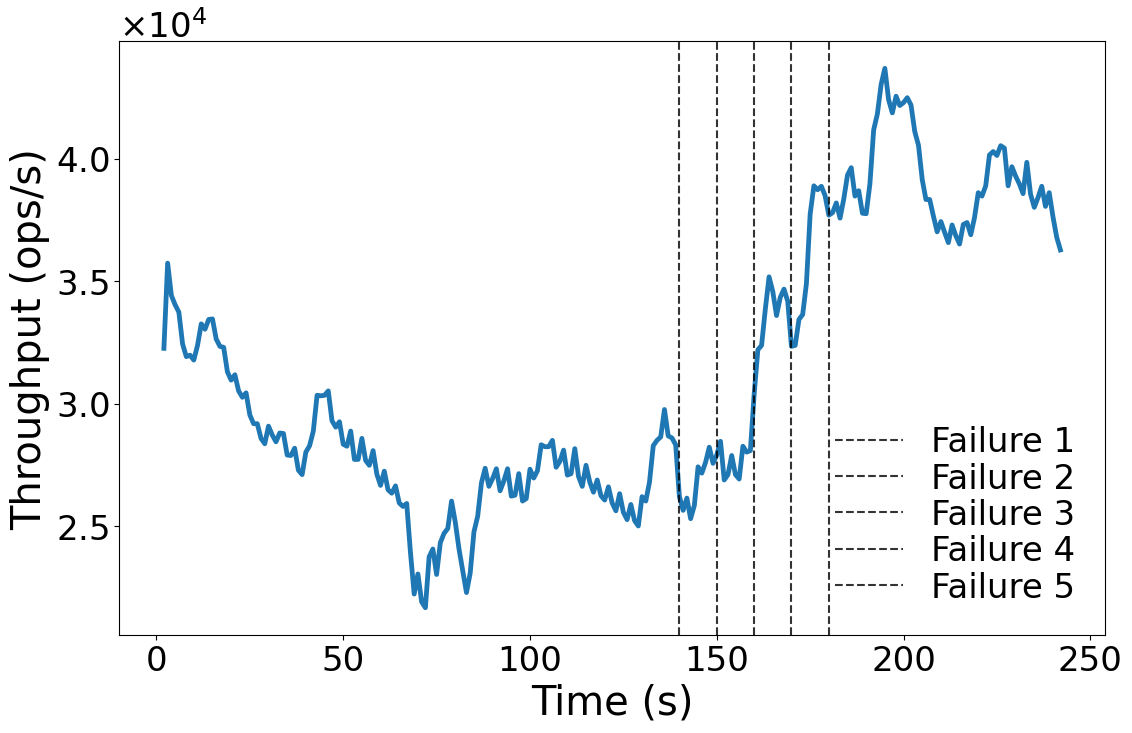

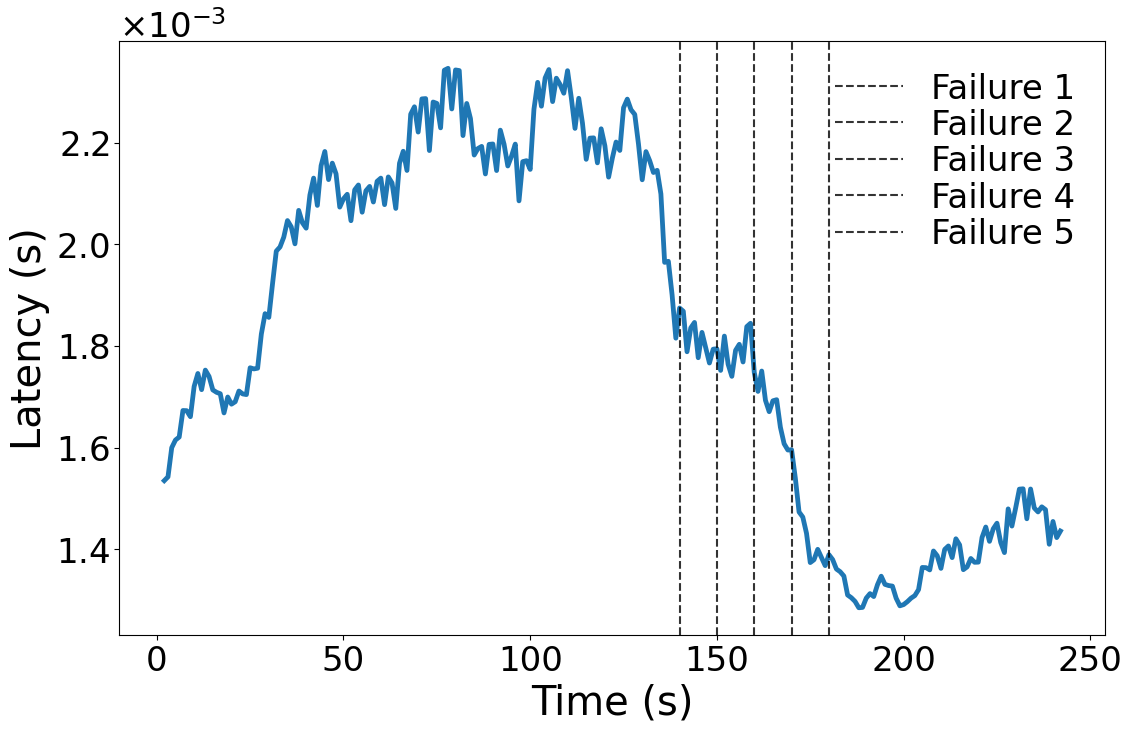

In [23]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.12,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



window = 5  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index[:-5],
        throughput_ma.values[:-5],
        "-"
    )

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s)")
# plt.title("Throughput vs Time (During Collection)")

for i in range(5):
    
    plt.axvline(
        x=140 + i * 10, color = 'black',linewidth=1.5,
        linestyle="--",
        alpha=0.8, label = 'Failure ' + str(i+1)
    )


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/failure_thput.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index[:-5],
        latency_ma.values[:-5],
        "-"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s)")
# plt.title("Proposal to Commit Latency (During Collection)")

for i in range(5):
    
    plt.axvline(
        x=140 + i * 10, color = 'black',linewidth=1.5,
        linestyle="--",
        alpha=0.8, label = 'Failure ' + str(i+1)
    )
plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/failure_lat.pdf", dpi=150)
plt.show()
